# Machine Learning Model Journey Practice 2: Airplane Delay Regression

## Introduction
This practice focuses on building a machine learning model to predict airplane arrival delays using regression techniques. By analyzing historical flight data, we aim to uncover patterns and factors contributing to delays, providing insights that can enhance operational efficiency.

Understanding and predicting flight delays is crucial for improving airline service quality. This exercise leverages various datasets, including flight schedules, weather conditions, and airport information, to develop a robust predictive model that can assist in mitigating delays and optimizing travel experiences.

## Data Analysis Objectives
- Predict how much an airplane will be delayed upon arrival.
- Identify the reasons for delays and address issues or respond proactively to improve service quality.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# library for feature engineering and EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from IPython.display import Image
from datetime import datetime

# library for statistic
from scipy import stats
from scipy.stats import kruskal
from scipy.stats import f_oneway

# library for machine learning
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor

%matplotlib inline

## 1. Data Processing 1

### 1-1 Data Load

In [3]:
!pwd
path_lecture = "./drive/MyDrive/MLops/clip21_airplane_delay_regression/"
random_state = 1234

/content


In [4]:
# linux 계열은 \를 사용. window 계열은 /를 사용
# linux : C:\Users\Desktop\example\weather.csv
# window : C:/Users/Desktop/example/weather.csv

df_airlines = pd.read_csv(path_lecture+"data/airlines.csv")
df_flights = pd.read_csv(path_lecture+"data/flights.csv")
df_tzone_meta = pd.read_csv(path_lecture+"data/tzone_meta.csv")
df_airports = pd.read_csv(path_lecture+"data/airports.csv")
df_planes = pd.read_csv(path_lecture+"data/planes.csv")
df_weather = pd.read_csv(path_lecture+"data/weather.csv")

In [5]:
df_weather = pd.read_csv(path_lecture+"data/weather.csv")



# Check the necessity of the data, airline information

In [6]:
df_airlines.head(10)

,carrier,name
0,AA,American Airlines Inc.
1,AS,Alaska Airlines Inc.
2,B6,JetBlue Airways
3,DL,Delta Air Lines Inc.
4,EV,ExpressJet Airlines Inc.
5,F9,Frontier Airlines Inc.
6,HA,Hawaiian Airlines Inc.
7,NK,Spirit Air Lines
8,OO,SkyWest Airlines Inc.
9,UA,United Air Lines Inc.


In [7]:
# checking on flight records
# Check for Missing Values in Flight History
# 1. Does it significantly impact data analysis?
# 2. If it affects problem-solving, how should it be handled (e.g., filling in missing values or removing them)?df_flights.head(3)

In [8]:
# Check for Missing Values in Flight History
# 1. Does it significantly impact data analysis?
# 2. If it affects problem-solving, how should it be handled (e.g., filling in missing values or removing them)?
df_flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303748 entries, 0 to 303747
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            303748 non-null  int64  
 1   month           303748 non-null  int64  
 2   day             303748 non-null  int64  
 3   dep_time        295938 non-null  float64
 4   sched_dep_time  303748 non-null  int64  
 5   dep_delay       295934 non-null  float64
 6   arr_time        295600 non-null  float64
 7   sched_arr_time  303748 non-null  int64  
 8   arr_delay       294896 non-null  float64
 9   carrier         303748 non-null  object 
 10  flight          303748 non-null  int64  
 11  tailnum         302757 non-null  object 
 12  origin          303748 non-null  object 
 13  dest            303748 non-null  object 
 14  air_time        294896 non-null  float64
 15  distance        303748 non-null  float64
 16  hour            303748 non-null  float64
 17  minute    

In [9]:
# This line of code is used to calculate and display the total number of missing values
df_flights.isna().sum()

,0
year,0
month,0
day,0
dep_time,7810
sched_dep_time,0
dep_delay,7814
arr_time,8148
sched_arr_time,0
arr_delay,8852
carrier,0


##### Missing Value Handling

Missing target values are problematic for machine learning models. Removing them is a common strategy to prepare the data for model training.

In [10]:
df_flights.dropna(subset=["arr_delay"]).info()

<class 'pandas.core.frame.DataFrame'>
Index: 294896 entries, 0 to 303738
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            294896 non-null  int64  
 1   month           294896 non-null  int64  
 2   day             294896 non-null  int64  
 3   dep_time        294896 non-null  float64
 4   sched_dep_time  294896 non-null  int64  
 5   dep_delay       294896 non-null  float64
 6   arr_time        294896 non-null  float64
 7   sched_arr_time  294896 non-null  int64  
 8   arr_delay       294896 non-null  float64
 9   carrier         294896 non-null  object 
 10  flight          294896 non-null  int64  
 11  tailnum         294896 non-null  object 
 12  origin          294896 non-null  object 
 13  dest            294896 non-null  object 
 14  air_time        294896 non-null  float64
 15  distance        294896 non-null  float64
 16  hour            294896 non-null  float64
 17  minute         

In [11]:
df_flights.head(3)

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2017,10,1,27.0,2114,193.0,317.0,15,182.0,UA,1537,N54711,EWR,MIA,148.0,1085.0,21.0,14.0,2017-10-01 21:00:00
1,2017,10,1,519.0,525,-6.0,741.0,759,-18.0,UA,1161,N37287,EWR,IAH,183.0,1400.0,5.0,25.0,2017-10-01 05:00:00
2,2017,10,1,544.0,545,-1.0,815.0,819,-4.0,B6,27,N547JB,EWR,MCO,133.0,937.0,5.0,45.0,2017-10-01 05:00:00


In [12]:
# drop rows that do not contain arr_delay since arr_delay is target data,
df_flights = df_flights.dropna(subset=["arr_delay"]).copy()

In [13]:
# timezone
df_tzone_meta.head(3)
# Seems timezone is unnecessary data

,tzone,tzone_name
0,1,America/New_York
1,2,America/Chicago
2,3,America/Denver


In [14]:
# airport info
df_airports.head(3)

,faa,name,lat,lon,alt,tz,dst,tzone
0,0V4,Brookneal/Campbell County Airport,37.141701,-79.016403,596,-5.0,A,1.0
1,19S,Sublette Municipal Airport,37.491402,-100.830002,2908,-5.0,A,NaN
2,23M,Clarke County Airport,32.084900,-88.738899,320,-6.0,A,2.0


In [15]:
# checking on missing values
df_airports.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1333 entries, 0 to 1332
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   faa     1333 non-null   object 
 1   name    1333 non-null   object 
 2   lat     1333 non-null   float64
 3   lon     1333 non-null   float64
 4   alt     1333 non-null   int64  
 5   tz      1277 non-null   float64
 6   dst     1277 non-null   object 
 7   tzone   1199 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 83.4+ KB


In [16]:
# Examine whether df_flights and df_airports can be joined
# df_flights has two airport-related keys: dest and origin
# df_airports has faa as the key
df_airports.faa.unique()

array(['0V4', '19S', '23M', ..., 'ZSY', 'ZUN', 'ZZV'], dtype=object)

In [17]:
# Examine whether df_airports can be joined based on the dest column in df_flights
# https://numpy.org/doc/stable/reference/generated/numpy.intersect1d.html
np.intersect1d(df_flights.dest.unique(), df_airports.faa.unique())

array(['ABQ', 'ACK', 'ALB', 'ANC', 'ATL', 'AUS', 'AVL', 'AVP', 'BDL',
       'BGR', 'BHM', 'BNA', 'BOS', 'BTV', 'BUF', 'BUR', 'BWI', 'BZN',
       'CAE', 'CAK', 'CHA', 'CHO', 'CHS', 'CLE', 'CLT', 'CMH', 'CVG',
       'DAB', 'DAL', 'DAY', 'DCA', 'DEN', 'DFW', 'DSM', 'DTW', 'EGE',
       'FLL', 'FNT', 'FWA', 'GRR', 'GSO', 'GSP', 'HDN', 'HNL', 'HOU',
       'HYA', 'IAD', 'IAH', 'ILM', 'IND', 'JAC', 'JAX', 'LAS', 'LAX',
       'LEX', 'LGB', 'MCI', 'MCO', 'MDW', 'MEM', 'MHT', 'MIA', 'MKE',
       'MSN', 'MSP', 'MSY', 'MTJ', 'MVY', 'MYR', 'OAK', 'OMA', 'ORD',
       'ORF', 'PBI', 'PDX', 'PHL', 'PHX', 'PIT', 'PSP', 'PVD', 'PWM',
       'RDU', 'RIC', 'RNO', 'ROC', 'RSW', 'SAN', 'SAT', 'SAV', 'SBN',
       'SDF', 'SEA', 'SFO', 'SJC', 'SLC', 'SMF', 'SNA', 'SRQ', 'STL',
       'SYR', 'TPA', 'TUS', 'TVC', 'TYS', 'XNA'], dtype=object)

In [18]:
# Examine whether df_flight and df_airport can be joined on 'origin'
np.intersect1d(df_flights.origin.unique(), df_airports.faa.unique())

array(['EWR', 'JFK', 'LGA'], dtype=object)

In [19]:
# show aircraft info
df_planes.head(3)

,tailnum,year,type,manufacturer,model,engines,seats,speed,engine
0,N102AA,2007.0,Fixed wing single engine,AVIAT AIRCRAFT INC,A-1B,1,2.0,NaN,Reciprocating
1,N103AA,2007.0,Fixed wing single engine,AVIAT AIRCRAFT INC,A-1B,1,2.0,NaN,Reciprocating
2,N103SY,2014.0,Fixed wing multi engine,EMBRAER S A,ERJ 170-200 LR,2,88.0,NaN,Turbo-fan


In [20]:
# Checking on missing values and columns
df_planes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3521 entries, 0 to 3520
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   tailnum       3521 non-null   object 
 1   year          3419 non-null   float64
 2   type          3521 non-null   object 
 3   manufacturer  3521 non-null   object 
 4   model         3521 non-null   object 
 5   engines       3521 non-null   int64  
 6   seats         3511 non-null   float64
 7   speed         62 non-null     float64
 8   engine        3521 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 247.7+ KB


In [21]:
df_planes.isna().sum()

,0
tailnum,0
year,102
type,0
manufacturer,0
model,0
engines,0
seats,10
speed,3459
engine,0


In [22]:
# Remove the speed column since it mostly consists of missing values
df_planes = df_planes.drop("speed", axis=1)

In [23]:
# Weather data
df_weather = pd.read_csv(path_lecture+"data/weather.csv")
df_weather.head(3)

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2017.0,1.0,1,0,NaN,NaN,NaN,200.0,17.26170,19.864419,NaN,NaN,10.0,2017-01-01 08:00:00
1,EWR,2017.0,1.0,1,1,NaN,NaN,NaN,220.0,16.11092,18.540125,NaN,NaN,10.0,2017-01-01 09:00:00
2,EWR,2017.0,1.0,1,2,NaN,NaN,NaN,190.0,11.50780,13.242946,NaN,NaN,10.0,2017-01-01 10:00:00


In [24]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26201 entries, 0 to 26200
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26201 non-null  object 
 1   year        26201 non-null  float64
 2   month       26201 non-null  float64
 3   day         26201 non-null  int64  
 4   hour        26201 non-null  int64  
 5   temp        559 non-null    float64
 6   dewp        559 non-null    float64
 7   humid       559 non-null    float64
 8   wind_dir    23540 non-null  float64
 9   wind_speed  23554 non-null  float64
 10  wind_gust   23554 non-null  float64
 11  precip      1370 non-null   float64
 12  pressure    433 non-null    float64
 13  visib       26190 non-null  float64
 14  time_hour   26201 non-null  object 
dtypes: float64(11), int64(2), object(2)
memory usage: 3.0+ MB


In [25]:
# the values from temp, dewp, humid, precip, pressure are missing -> remove
df_weather = df_weather.drop(["temp", "dewp", "humid","precip","pressure"], axis=1)
df_weather

,origin,year,month,day,hour,wind_dir,wind_speed,wind_gust,visib,time_hour
0,EWR,2017.0,1.0,1,0,200.0,17.26170,19.864419,10.0,2017-01-01 08:00:00
1,EWR,2017.0,1.0,1,1,220.0,16.11092,18.540125,10.0,2017-01-01 09:00:00
2,EWR,2017.0,1.0,1,2,190.0,11.50780,13.242946,10.0,2017-01-01 10:00:00
3,EWR,2017.0,1.0,1,3,190.0,8.05546,9.270062,10.0,2017-01-01 11:00:00
4,EWR,2017.0,1.0,1,4,220.0,9.20624,10.594357,10.0,2017-01-01 12:00:00
...,...,...,...,...,...,...,...,...,...,...
26196,LGA,2017.0,12.0,30,19,210.0,9.20624,10.594357,5.0,2017-12-31 03:00:00
26197,LGA,2017.0,12.0,30,20,200.0,10.35702,11.918651,10.0,2017-12-31 04:00:00
26198,LGA,2017.0,12.0,30,21,280.0,8.05546,9.270062,10.0,2017-12-31 05:00:00
26199,LGA,2017.0,12.0,30,22,260.0,10.35702,11.918651,10.0,2017-12-31 06:00:00


In [26]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26201 entries, 0 to 26200
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26201 non-null  object 
 1   year        26201 non-null  float64
 2   month       26201 non-null  float64
 3   day         26201 non-null  int64  
 4   hour        26201 non-null  int64  
 5   wind_dir    23540 non-null  float64
 6   wind_speed  23554 non-null  float64
 7   wind_gust   23554 non-null  float64
 8   visib       26190 non-null  float64
 9   time_hour   26201 non-null  object 
dtypes: float64(6), int64(2), object(2)
memory usage: 2.0+ MB


In [27]:
df_weather.head(3)

,origin,year,month,day,hour,wind_dir,wind_speed,wind_gust,visib,time_hour
0,EWR,2017.0,1.0,1,0,200.0,17.26170,19.864419,10.0,2017-01-01 08:00:00
1,EWR,2017.0,1.0,1,1,220.0,16.11092,18.540125,10.0,2017-01-01 09:00:00
2,EWR,2017.0,1.0,1,2,190.0,11.50780,13.242946,10.0,2017-01-01 10:00:00


##### Missing Value Handling 2
* Weather data is likely to be similar to the immediately preceding and following weather, so we use this to fill in missing values.
* The fillna method with ffill (forward fill) and bfill (backward fill) is applied to all columns in df_weather within each origin group, not just specific ones. This assumes that all weather-related columns (e.g., temperature, wind speed, etc.) exhibit temporal continuity and can be filled based on adjacent time points.

In [28]:
# Forward fill missing values in df_weather, sorted by origin and time_hour, grouped by origin
df_weather.sort_values(["origin", "time_hour"]).groupby("origin").apply(lambda x : x.fillna(method="ffill"))
# Backward fill missing values in df_weather, sorted by origin and time_hour, grouped by origin, then display dataframe info
df_weather.sort_values(["origin", "time_hour"]).groupby("origin").apply(lambda x : x.fillna(method="bfill")).info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 26201 entries, ('EWR', np.int64(0)) to ('LGA', np.int64(26200))
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26201 non-null  object 
 1   year        26201 non-null  float64
 2   month       26201 non-null  float64
 3   day         26201 non-null  int64  
 4   hour        26201 non-null  int64  
 5   wind_dir    26201 non-null  float64
 6   wind_speed  26201 non-null  float64
 7   wind_gust   26201 non-null  float64
 8   visib       26201 non-null  float64
 9   time_hour   26201 non-null  object 
dtypes: float64(6), int64(2), object(2)
memory usage: 3.3+ MB


<ipython-input-28-71f5331cfa8b>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_weather.sort_values(["origin", "time_hour"]).groupby("origin").apply(lambda x : x.fillna(method="ffill"))
<ipython-input-28-71f5331cfa8b>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_weather.sort_values(["origin", "time_hour"]).groupby("origin").apply(lambda x : x.fillna(method="ffill"))
<ipython-input-28-71f5331cfa8b>:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_weather.sort_values(["origin", "time_hour"]).groupby("ori

In [29]:
df_weather = df_weather.groupby("origin", group_keys=False).apply(lambda x: x.ffill().bfill())
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26201 entries, 0 to 26200
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26201 non-null  object 
 1   year        26201 non-null  float64
 2   month       26201 non-null  float64
 3   day         26201 non-null  int64  
 4   hour        26201 non-null  int64  
 5   wind_dir    26201 non-null  float64
 6   wind_speed  26201 non-null  float64
 7   wind_gust   26201 non-null  float64
 8   visib       26201 non-null  float64
 9   time_hour   26201 non-null  object 
dtypes: float64(6), int64(2), object(2)
memory usage: 2.2+ MB


<ipython-input-29-182ebfe97274>:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_weather = df_weather.groupby("origin", group_keys=False).apply(lambda x: x.ffill().bfill())


In [30]:
df_weather.isna().sum()

,0
origin,0
year,0
month,0
day,0
hour,0
wind_dir,0
wind_speed,0
wind_gust,0
visib,0
time_hour,0


### 1-3 Data Join

##### Join Process
##### 1. Join df_flights with df_airports
- Join can be done using `df_flights["dest"]` with `df_airports["faa"]` or `df_flights["origin"]` with `df_airports["faa"]`. However, since the number of airports in `origin` is smaller, we proceed with the join only on `dest`.
- Combines flight information with detailed airport information from `df_airports`.
```python
# Join df_flights with df_airports on dest
df_flights_with_airports = df_flights.merge(df_airports, left_on="dest", right_on="faa", how="left")

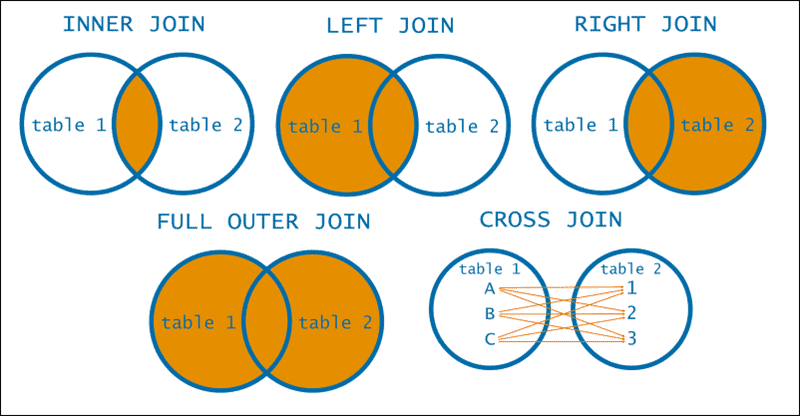

In [31]:
Image(path_lecture+"img/jointypes.png")

In [32]:
# 1. Join df_flights with df_airports
df_flight_and_airport = pd.merge(df_flights, df_airports, how='left', left_on='dest', right_on='faa')
df_flight_and_airport['tailnum'].head(5)

,tailnum
0,N54711
1,N37287
2,N547JB
3,N38446
4,N675NK


In [33]:
df_planes.head(3)

,tailnum,year,type,manufacturer,model,engines,seats,engine
0,N102AA,2007.0,Fixed wing single engine,AVIAT AIRCRAFT INC,A-1B,1,2.0,Reciprocating
1,N103AA,2007.0,Fixed wing single engine,AVIAT AIRCRAFT INC,A-1B,1,2.0,Reciprocating
2,N103SY,2014.0,Fixed wing multi engine,EMBRAER S A,ERJ 170-200 LR,2,88.0,Turbo-fan


### Step 2.
* suffixes=("_flights","_planes"):
  - This is a safety measure. Since both dataframes might contain columns with the same name (other than tailnum), this argument adds suffixes to those columns in the merged dataframe to prevent ambiguity.
  - For example, if both dataframes have a 'year' column, they'll become 'year_flights' and 'year_planes' in df_f_a_p.

In [34]:
# 2. Join df_flight_and_airport with df_planes
# If there are identical column names, they can be distinguished during the join using suffixes.
df_f_a_p = pd.merge(df_flight_and_airport, df_planes, how='left', on='tailnum', suffixes=("_flights","_planes"))
df_f_a_p.head(2)

,year_flights,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,tz,dst,tzone,year_planes,type,manufacturer,model,engines,seats,engine
0,2017,10,1,27.0,2114,193.0,317.0,15,182.0,UA,...,-5.0,A,1.0,1998.0,Fixed wing multi engine,BOEING,737-724,2.0,149.0,Turbo-fan
1,2017,10,1,519.0,525,-6.0,741.0,759,-18.0,UA,...,-6.0,A,2.0,2004.0,Fixed wing multi engine,BOEING,737-824,2.0,149.0,Turbo-fan


### Step 3.
#### Join the Result from Step 2 with df_weather
- Two types of weather information can potentially be joined:
  - Weather information at the departure time.
  - Weather information at the arrival time: Not pursued due to ambiguity in the given data.
    - If feasible, it would be beneficial to proceed with this as well.

#### Join the result from Step 2 with df_weather for departure time weather

In [35]:
df_f_a_p["time_hour"].head(3)

,time_hour
0,2017-10-01 21:00:00
1,2017-10-01 05:00:00
2,2017-10-01 05:00:00


In [36]:
# Convert time_hour to datetime format for further adjustments
df_f_a_p["dest_datetime"] = pd.to_datetime(df_f_a_p["time_hour"])

# Since time_hour reflects the scheduled departure time, we need to add the actual delayed departure time to it.
# Additionally, as time_hour excludes minute-level data, the minutes column data should also be added.
df_f_a_p["dest_datetime"] = df_f_a_p.apply(lambda x : x.dest_datetime
                                           + pd.Timedelta(minutes=x.dep_delay)
                                           + pd.Timedelta(minutes=x.minute), axis=1)

In [37]:
df_f_a_p["dest_datetime"].head(5)

,dest_datetime
0,2017-10-02 00:27:00
1,2017-10-01 05:19:00
2,2017-10-01 05:44:00
3,2017-10-01 05:46:00
4,2017-10-01 05:52:00


In [38]:
df_f_a_p.head(3)

,year_flights,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,dst,tzone,year_planes,type,manufacturer,model,engines,seats,engine,dest_datetime
0,2017,10,1,27.0,2114,193.0,317.0,15,182.0,UA,...,A,1.0,1998.0,Fixed wing multi engine,BOEING,737-724,2.0,149.0,Turbo-fan,2017-10-02 00:27:00
1,2017,10,1,519.0,525,-6.0,741.0,759,-18.0,UA,...,A,2.0,2004.0,Fixed wing multi engine,BOEING,737-824,2.0,149.0,Turbo-fan,2017-10-01 05:19:00
2,2017,10,1,544.0,545,-1.0,815.0,819,-4.0,B6,...,A,1.0,2002.0,Fixed wing multi engine,AIRBUS,A320-232,2.0,200.0,Turbo-fan,2017-10-01 05:44:00


In [39]:
df_weather.head(2)

,origin,year,month,day,hour,wind_dir,wind_speed,wind_gust,visib,time_hour
0,EWR,2017.0,1.0,1,0,200.0,17.26170,19.864419,10.0,2017-01-01 08:00:00
1,EWR,2017.0,1.0,1,1,220.0,16.11092,18.540125,10.0,2017-01-01 09:00:00


In [40]:
df_f_a_p["dest_datetime"]

,dest_datetime
0,2017-10-02 00:27:00
1,2017-10-01 05:19:00
2,2017-10-01 05:44:00
3,2017-10-01 05:46:00
4,2017-10-01 05:52:00
...,...
294891,2017-09-30 22:38:00
294892,2017-09-30 22:41:00
294893,2017-09-30 22:48:00
294894,2017-09-30 23:19:00


In [41]:
# Remove minute information from dest_datetime to enable joining with weather data
df_f_a_p["dest_datetime"] = df_f_a_p["dest_datetime"].dt.strftime("%Y-%m-%d %H:00:00")
df_f_a_p.head(1)

,year_flights,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,dst,tzone,year_planes,type,manufacturer,model,engines,seats,engine,dest_datetime
0,2017,10,1,27.0,2114,193.0,317.0,15,182.0,UA,...,A,1.0,1998.0,Fixed wing multi engine,BOEING,737-724,2.0,149.0,Turbo-fan,2017-10-02 00:00:00


In [42]:
df_f_a_p["dest_datetime"]

,dest_datetime
0,2017-10-02 00:00:00
1,2017-10-01 05:00:00
2,2017-10-01 05:00:00
3,2017-10-01 05:00:00
4,2017-10-01 05:00:00
...,...
294891,2017-09-30 22:00:00
294892,2017-09-30 22:00:00
294893,2017-09-30 22:00:00
294894,2017-09-30 23:00:00


In [43]:
# Rename time_hour to dest_datetime in df_weather for consistency with join
df_weather = df_weather.rename(columns={'time_hour': 'dest_datetime' })

In [44]:
df_f_a_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294896 entries, 0 to 294895
Data columns (total 35 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year_flights    294896 non-null  int64  
 1   month           294896 non-null  int64  
 2   day             294896 non-null  int64  
 3   dep_time        294896 non-null  float64
 4   sched_dep_time  294896 non-null  int64  
 5   dep_delay       294896 non-null  float64
 6   arr_time        294896 non-null  float64
 7   sched_arr_time  294896 non-null  int64  
 8   arr_delay       294896 non-null  float64
 9   carrier         294896 non-null  object 
 10  flight          294896 non-null  int64  
 11  tailnum         294896 non-null  object 
 12  origin          294896 non-null  object 
 13  dest            294896 non-null  object 
 14  air_time        294896 non-null  float64
 15  distance        294896 non-null  float64
 16  hour            294896 non-null  float64
 17  minute    

In [45]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26201 entries, 0 to 26200
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   origin         26201 non-null  object 
 1   year           26201 non-null  float64
 2   month          26201 non-null  float64
 3   day            26201 non-null  int64  
 4   hour           26201 non-null  int64  
 5   wind_dir       26201 non-null  float64
 6   wind_speed     26201 non-null  float64
 7   wind_gust      26201 non-null  float64
 8   visib          26201 non-null  float64
 9   dest_datetime  26201 non-null  object 
dtypes: float64(6), int64(2), object(2)
memory usage: 3.2+ MB


In [46]:
df_final = pd.merge(df_f_a_p, df_weather, how="left", on=["origin","dest_datetime"], suffixes=("", "_weather"))
# _x, _y

In [47]:
df_final.head()

,year_flights,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,engine,dest_datetime,year,month_weather,day_weather,hour_weather,wind_dir,wind_speed,wind_gust,visib
0,2017,10,1,27.0,2114,193.0,317.0,15,182.0,UA,...,Turbo-fan,2017-10-02 00:00:00,2017.0,10.0,1.0,17.0,40.0,9.20624,10.594357,10.0
1,2017,10,1,519.0,525,-6.0,741.0,759,-18.0,UA,...,Turbo-fan,2017-10-01 05:00:00,2017.0,9.0,30.0,22.0,360.0,16.11092,18.540125,10.0
2,2017,10,1,544.0,545,-1.0,815.0,819,-4.0,B6,...,Turbo-fan,2017-10-01 05:00:00,2017.0,9.0,30.0,22.0,360.0,16.11092,18.540125,10.0
3,2017,10,1,546.0,550,-4.0,702.0,719,-17.0,UA,...,Turbo-fan,2017-10-01 05:00:00,2017.0,9.0,30.0,22.0,360.0,19.56326,22.513008,10.0
4,2017,10,1,552.0,600,-8.0,846.0,850,-4.0,NK,...,Turbo-fan,2017-10-01 05:00:00,2017.0,9.0,30.0,22.0,360.0,16.11092,18.540125,10.0


### 1-4 Checking for Duplicate Data
#### 1. Issues with the join process
#### 2. Problems with the data collection system
#### 3. Issues in the data preparation process for training

In [48]:
# df_final.duplicated()-  It flags each row as True if it is a duplicate of
# a previous row, and False otherwise
print( "Duplicated Data :", len(df_final[df_final.duplicated()]))

Duplicated Data : 0


## 2. Data EDA

### 2-1 Data Type and Summary

In [49]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294896 entries, 0 to 294895
Data columns (total 43 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year_flights    294896 non-null  int64  
 1   month           294896 non-null  int64  
 2   day             294896 non-null  int64  
 3   dep_time        294896 non-null  float64
 4   sched_dep_time  294896 non-null  int64  
 5   dep_delay       294896 non-null  float64
 6   arr_time        294896 non-null  float64
 7   sched_arr_time  294896 non-null  int64  
 8   arr_delay       294896 non-null  float64
 9   carrier         294896 non-null  object 
 10  flight          294896 non-null  int64  
 11  tailnum         294896 non-null  object 
 12  origin          294896 non-null  object 
 13  dest            294896 non-null  object 
 14  air_time        294896 non-null  float64
 15  distance        294896 non-null  float64
 16  hour            294896 non-null  float64
 17  minute    

In [50]:
df_final.isna().sum()

,0
year_flights,0
month,0
day,0
dep_time,0
sched_dep_time,0
dep_delay,0
arr_time,0
sched_arr_time,0
arr_delay,0
carrier,0


In [51]:
# Heuristically check to separate categorical data from numerical data
# 1. Data specification sheet
# 2. Check unique values for each data column using unique() -> Inspect the unique values
for column_name in list(df_final.columns):
    print(column_name, type(df_final[column_name][0]), df_final[column_name].unique())

year_flights <class 'numpy.int64'> [2017]
month <class 'numpy.int64'> [10 11 12  1  2  3  4  5  6  7  8  9]
day <class 'numpy.int64'> [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
dep_time <class 'numpy.float64'> [ 27. 519. 544. ... 254. 425. 400.]
sched_dep_time <class 'numpy.int64'> [2114  525  545 ... 2231 2111 2354]
dep_delay <class 'numpy.float64'> [ 1.930e+02 -6.000e+00 -1.000e+00 -4.000e+00 -8.000e+00 -7.000e+00
 -1.200e+01 -5.000e+00 -3.000e+00 -9.000e+00  7.330e+02  0.000e+00
  3.300e+01  1.000e+00 -1.100e+01 -1.000e+01 -2.000e+00  1.200e+01
 -1.400e+01  5.000e+00  3.000e+00  2.000e+00  1.500e+01  1.400e+01
  3.400e+01  5.200e+01  1.530e+02 -1.700e+01 -1.600e+01  7.000e+00
 -1.300e+01  2.200e+01  8.000e+00  6.100e+01 -2.100e+01  7.600e+01
  2.800e+01  4.000e+00  9.000e+00  1.020e+02  1.080e+02 -1.500e+01
  1.800e+01  5.000e+01  1.900e+01  6.000e+00  4.900e+01  2.000e+01
  1.000e+01  3.000e+01  2.300e+01  5.600e+01  1.600e+01  6

### Since int type columns can also exhibit categorical characteristics, in such cases, columns are heuristically distinguished.

In [52]:
df_final.select_dtypes(include=['int64']).columns

Index(['year_flights', 'month', 'day', 'sched_dep_time', 'sched_arr_time',
       'flight'],
      dtype='object')

### When float type columns do not exhibit numeric characteristics, in such cases,
  - columns are heuristically distinguished.

In [53]:
df_final.select_dtypes(include=['float64']).columns

Index(['dep_time', 'dep_delay', 'arr_time', 'arr_delay', 'air_time',
       'distance', 'hour', 'minute', 'lat', 'lon', 'alt', 'tz', 'tzone',
       'year_planes', 'engines', 'seats', 'year', 'month_weather',
       'day_weather', 'hour_weather', 'wind_dir', 'wind_speed', 'wind_gust',
       'visib'],
      dtype='object')

 - `dep_time` and `arr_time` represent time, and since `hour` and `minute` data are in datetime format (%H%M), they require conversion.
 - `wind_dir` is also considered categorical due to its nature (representing angles).

In [54]:
df_final["dep_time"]

,dep_time
0,27.0
1,519.0
2,544.0
3,546.0
4,552.0
...,...
294891,2238.0
294892,2241.0
294893,2248.0
294894,2319.0


In [55]:
df_final["arr_time"]

,arr_time
0,317.0
1,741.0
2,815.0
3,702.0
4,846.0
...,...
294891,2338.0
294892,2353.0
294893,43.0
294894,9.0


In [56]:
df_final["dep_time"] = df_final["dep_time"].apply(lambda x: '{0:04d}'.format(int(x)))
df_final["arr_time"] = df_final["arr_time"].apply(lambda x: '{0:04d}'.format(int(x)))
df_final["wind_dir"] = df_final["wind_dir"].astype("str")

In [57]:
df_final.head(3)

,year_flights,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,engine,dest_datetime,year,month_weather,day_weather,hour_weather,wind_dir,wind_speed,wind_gust,visib
0,2017,10,1,0027,2114,193.0,0317,15,182.0,UA,...,Turbo-fan,2017-10-02 00:00:00,2017.0,10.0,1.0,17.0,40.0,9.20624,10.594357,10.0
1,2017,10,1,0519,525,-6.0,0741,759,-18.0,UA,...,Turbo-fan,2017-10-01 05:00:00,2017.0,9.0,30.0,22.0,360.0,16.11092,18.540125,10.0
2,2017,10,1,0544,545,-1.0,0815,819,-4.0,B6,...,Turbo-fan,2017-10-01 05:00:00,2017.0,9.0,30.0,22.0,360.0,16.11092,18.540125,10.0


In [58]:
list_categorical_columns = list(df_final.select_dtypes(include=['int64', 'object']).columns)
list_numeric_columns = list(df_final.select_dtypes(include=['float64']).columns)
target_column = "arr_delay"

In [59]:
print("list_categorical_columns - ",list_categorical_columns)
print("list_numeric_columns - ",list_numeric_columns)

list_categorical_columns -  ['year_flights', 'month', 'day', 'dep_time', 'sched_dep_time', 'arr_time', 'sched_arr_time', 'carrier', 'flight', 'tailnum', 'origin', 'dest', 'time_hour', 'faa', 'name', 'dst', 'type', 'manufacturer', 'model', 'engine', 'dest_datetime', 'wind_dir']
list_numeric_columns -  ['dep_delay', 'arr_delay', 'air_time', 'distance', 'hour', 'minute', 'lat', 'lon', 'alt', 'tz', 'tzone', 'year_planes', 'engines', 'seats', 'year', 'month_weather', 'day_weather', 'hour_weather', 'wind_speed', 'wind_gust', 'visib']


In [60]:
print(len(df_final.columns))
print(len(list_categorical_columns))
print(len(list_numeric_columns))

43
22
21


##### Summary of Data Set
##### Number of Variables : 43
    numeric variables : 21 (target 포함)
    categorical variables : 22
##### Number of observations : 294896
##### Duplicated Rows : 0

### 2-2 Explore Dependent Data

<Axes: xlabel='arr_delay', ylabel='Count'>

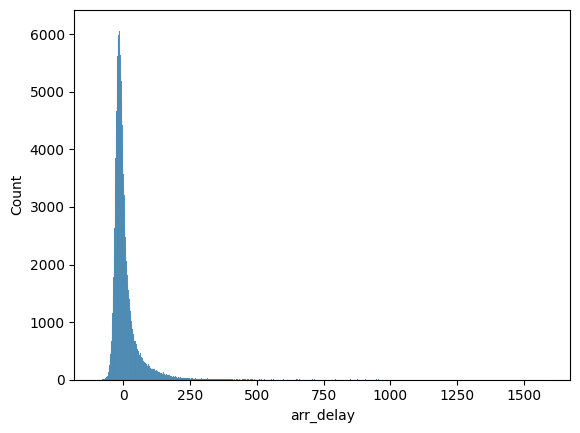

In [61]:
sns.histplot(data=df_final, x="arr_delay")


- Skewness indicates the asymmetry of the distribution: positive skew means a longer right tail (e.g., more extreme delays), while negative skew means a longer left tail.
- This is relevant to your airplane delay regression task for understanding the target variable’s distribution.

- Kurtosis measures the "tailedness" of the distribution: a high value indicates heavy tails (more extreme values), while a low value indicates light tails compared to a normal distribution.
- This is useful in your MLOps context to assess the presence of outliers or extreme delays in the target variable.

In [62]:
# https://ko.wikipedia.org/wiki/비대칭도
print(stats.skew(df_final["arr_delay"]))
# https://ko.wikipedia.org/wiki/첨도
print(stats.kurtosis(df_final["arr_delay"]))

5.559168844552731
64.17521265711945


- Kurtosis measures the "tailedness" of a distribution. A normal distribution has a kurtosis of 3 (or 0 in excess kurtosis terms, depending on the definition used by scipy.stats).
- A value of 64.18 is extremely high, indicating a leptokurtic distribution with very heavy tails and a sharp peak.

<Axes: xlabel='arr_delay'>

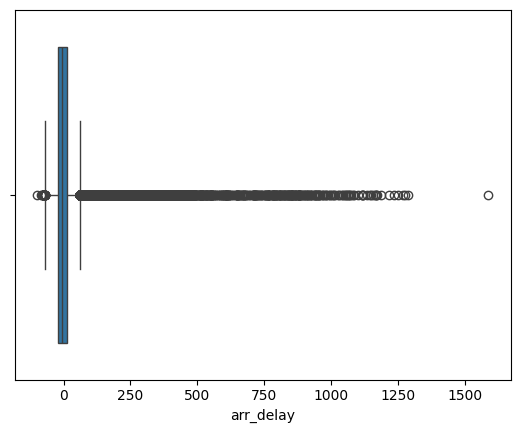

In [63]:
sns.boxplot(data=df_final, x="arr_delay")

<Axes: xlabel='arr_delay'>

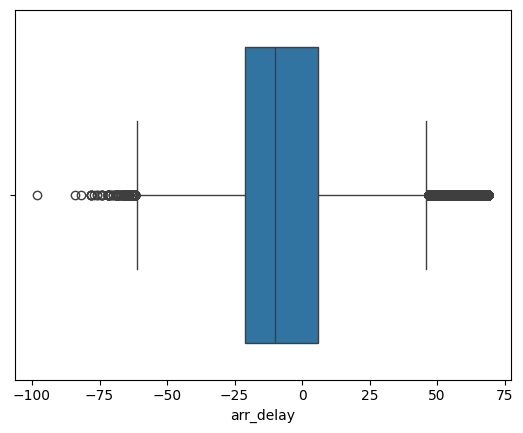

In [64]:
sns.boxplot(data=df_final[df_final.arr_delay < 70], x="arr_delay")

In [65]:
df_final["arr_delay"].describe()

,arr_delay
count,294896.000000
mean,7.104023
std,55.323259
min,-98.000000
25%,-20.000000
50%,-7.000000
75%,13.000000
max,1589.000000


### 2-3 Explore Independent Data

In [66]:
df_final.head()

,year_flights,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,engine,dest_datetime,year,month_weather,day_weather,hour_weather,wind_dir,wind_speed,wind_gust,visib
0,2017,10,1,0027,2114,193.0,0317,15,182.0,UA,...,Turbo-fan,2017-10-02 00:00:00,2017.0,10.0,1.0,17.0,40.0,9.20624,10.594357,10.0
1,2017,10,1,0519,525,-6.0,0741,759,-18.0,UA,...,Turbo-fan,2017-10-01 05:00:00,2017.0,9.0,30.0,22.0,360.0,16.11092,18.540125,10.0
2,2017,10,1,0544,545,-1.0,0815,819,-4.0,B6,...,Turbo-fan,2017-10-01 05:00:00,2017.0,9.0,30.0,22.0,360.0,16.11092,18.540125,10.0
3,2017,10,1,0546,550,-4.0,0702,719,-17.0,UA,...,Turbo-fan,2017-10-01 05:00:00,2017.0,9.0,30.0,22.0,360.0,19.56326,22.513008,10.0
4,2017,10,1,0552,600,-8.0,0846,850,-4.0,NK,...,Turbo-fan,2017-10-01 05:00:00,2017.0,9.0,30.0,22.0,360.0,16.11092,18.540125,10.0


In [67]:
print(path_lecture)

./drive/MyDrive/MLops/clip21_airplane_delay_regression/


In [68]:
df_final.describe().to_csv(path_lecture + "data/describe.csv")

#### Removing Unnecessary Columns



In [69]:
df_final.apply(lambda x : x.unique())

,0
year_flights,[2017]
month,"[10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
day,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
dep_time,"[0027, 0519, 0544, 0546, 0552, 0553, 0554, 055..."
sched_dep_time,"[2114, 525, 545, 550, 600, 607, 606, 610, 615,..."
dep_delay,"[193.0, -6.0, -1.0, -4.0, -8.0, -7.0, -12.0, -..."
arr_time,"[0317, 0741, 0815, 0702, 0846, 0852, 0844, 083..."
sched_arr_time,"[15, 759, 819, 719, 850, 858, 844, 853, 902, 8..."
arr_delay,"[182.0, -18.0, -4.0, -17.0, -6.0, 0.0, -22.0, ..."
carrier,"[UA, B6, NK, AA, DL, WN, EV, AS, OO, VX, F9, HA]"


##### Unnecessary Columns (May Vary for Each Person)
- `year_flights`: Excluded because all values are the same.
- `sched_dep_time`: Removed as scheduled time is not meaningful data.
- `arr_time`: Removed because it carries the same meaning as the target variable `arr_delay`, potentially causing data leakage.
- `sched_arr_time`: Removed as scheduled time is not meaningful data.
- `hour`: Removed since it is part of `sched_dep_time` (scheduled departure time is deemed irrelevant; actual departure time matters).
- `minute`: Removed since it is part of `sched_dep_time` (scheduled departure time is deemed irrelevant; actual departure time matters).
- `time_hour`: Removed because it was created based on scheduled departure time.
- `tz`: Excluded.
- `dst`: Excluded.
- `tzone`: Excluded.
- `year`: Excluded as it is the same as `year_flights` and only 2017 exists in the remaining data (same as in `flights.csv`).
- `month_weather`: Excluded as it is unnecessary (same as in `flights.csv`).
- `day_weather`: Excluded as it is unnecessary (same as in `flights.csv`).
- `hour_weather`: Excluded as it is unnecessary (same as in `flights.csv`).

In [70]:
df_final = df_final.drop(['year_flights', 'sched_dep_time', 'arr_time', 'sched_arr_time','hour', 'minute', 'time_hour','tz', 'dst', 'tzone', 'year', 'month_weather', 'day_weather', 'hour_weather'],axis=1).copy()
df_final.head(3)

,month,day,dep_time,dep_delay,arr_delay,carrier,flight,tailnum,origin,dest,...,manufacturer,model,engines,seats,engine,dest_datetime,wind_dir,wind_speed,wind_gust,visib
0,10,1,0027,193.0,182.0,UA,1537,N54711,EWR,MIA,...,BOEING,737-724,2.0,149.0,Turbo-fan,2017-10-02 00:00:00,40.0,9.20624,10.594357,10.0
1,10,1,0519,-6.0,-18.0,UA,1161,N37287,EWR,IAH,...,BOEING,737-824,2.0,149.0,Turbo-fan,2017-10-01 05:00:00,360.0,16.11092,18.540125,10.0
2,10,1,0544,-1.0,-4.0,B6,27,N547JB,EWR,MCO,...,AIRBUS,A320-232,2.0,200.0,Turbo-fan,2017-10-01 05:00:00,360.0,16.11092,18.540125,10.0


In [71]:
list_categorical_columns = list(df_final.select_dtypes(include=['int64', 'object']).columns)
list_numeric_columns = list(df_final.select_dtypes(include=['float64']).columns)
print(len(df_final.columns))
print("categorical columns : ",len(list_categorical_columns))
print("numerical columns : ", len(list_numeric_columns))

29
categorical columns :  16
numerical columns :  13


#### 1) exploring categorical column data

In [72]:
list_categorical_columns

['month',
 'day',
 'dep_time',
 'carrier',
 'flight',
 'tailnum',
 'origin',
 'dest',
 'faa',
 'name',
 'type',
 'manufacturer',
 'model',
 'engine',
 'dest_datetime',
 'wind_dir']

<Axes: xlabel='arr_delay', ylabel='origin'>

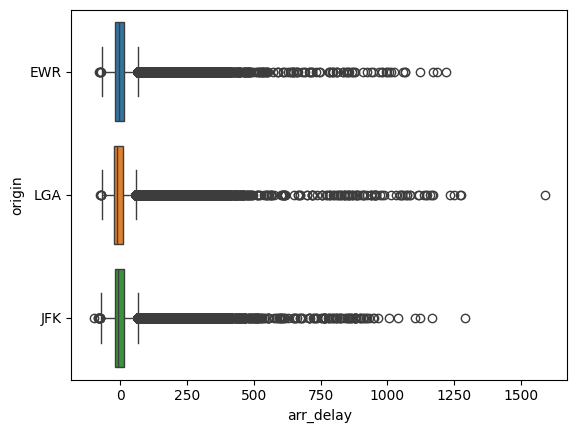

In [73]:
# Conduct various explorations to understand the data.
# 1) Explore whether there is a correlation between arr_delay and origin (departure location).
sns.boxplot(data=df_final, x="arr_delay", y="origin", hue="origin")

<Axes: xlabel='arr_delay', ylabel='origin'>

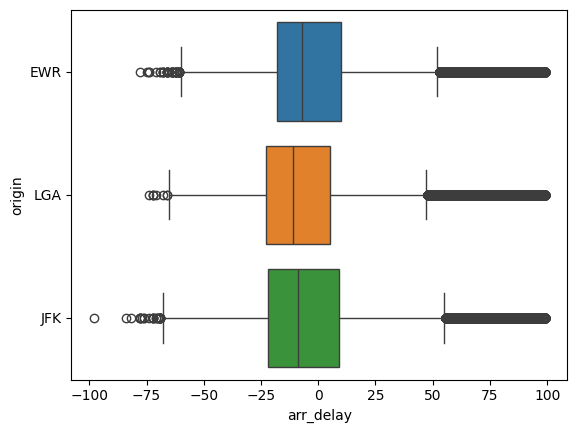

In [74]:
# Since it’s not clearly visible, apply a filter to observe the data again.
sns.boxplot(data=df_final[df_final.arr_delay < 100], x="arr_delay", y="origin", hue="origin")

<Axes: xlabel='arr_delay', ylabel='engine'>

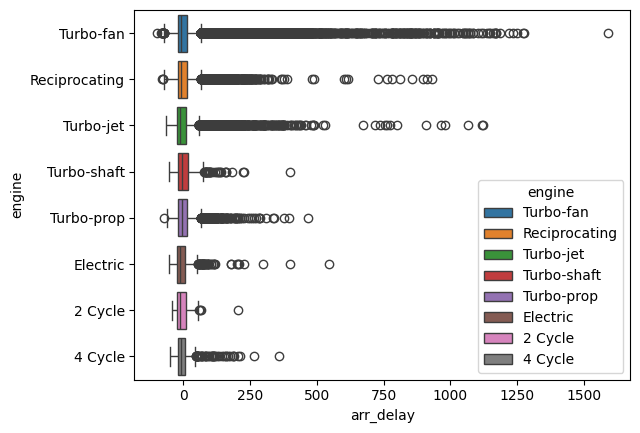

In [75]:
### 2-1) Does arr_delay vary depending on the airplane engine?
sns.boxplot(data=df_final, x="arr_delay", y="engine", hue="engine")

# The Turbo-fan engine shows a data distribution with longer arr_delay.
# The 2 Cycle engine exhibits relatively shorter arr_delay.

<Axes: xlabel='distance', ylabel='engine'>

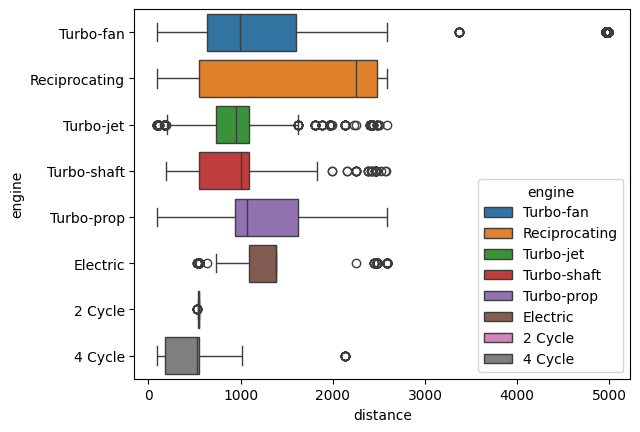

In [76]:
### 2-2) As observed in 2-1), arr_delay varies by engine. Could this be because certain engines are used more for longer distances? (Hypothesis and Exploration)
sns.boxplot(data=df_final, x="distance", y="engine", hue="engine")

# Reciprocating engines appear to be used more for relatively longer distance flights, but they tend to have less arr_delay compared to Turbo-fan (relatively speaking).

<Axes: xlabel='month', ylabel='arr_delay'>

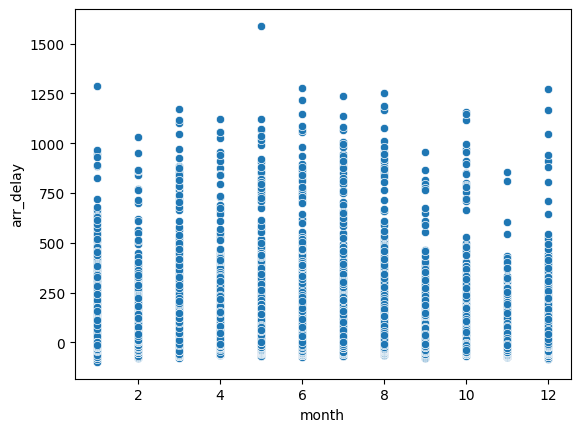

In [77]:
# When the number of distinct values in a categorical column is too large, a scatter plot can be used to check the overall distribution and interactions.
# 1) Exploration based on the month of operation
sns.scatterplot(data=df_final, x="month", y="arr_delay")

<Axes: xlabel='carrier', ylabel='arr_delay'>

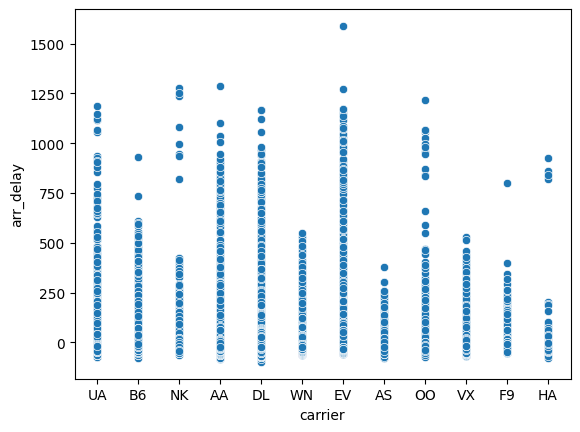

In [78]:
### 2-1) Exploration based on the airline of the aircraft
sns.scatterplot(data=df_final, x="carrier", y="arr_delay")

<Axes: xlabel='arr_delay', ylabel='carrier'>

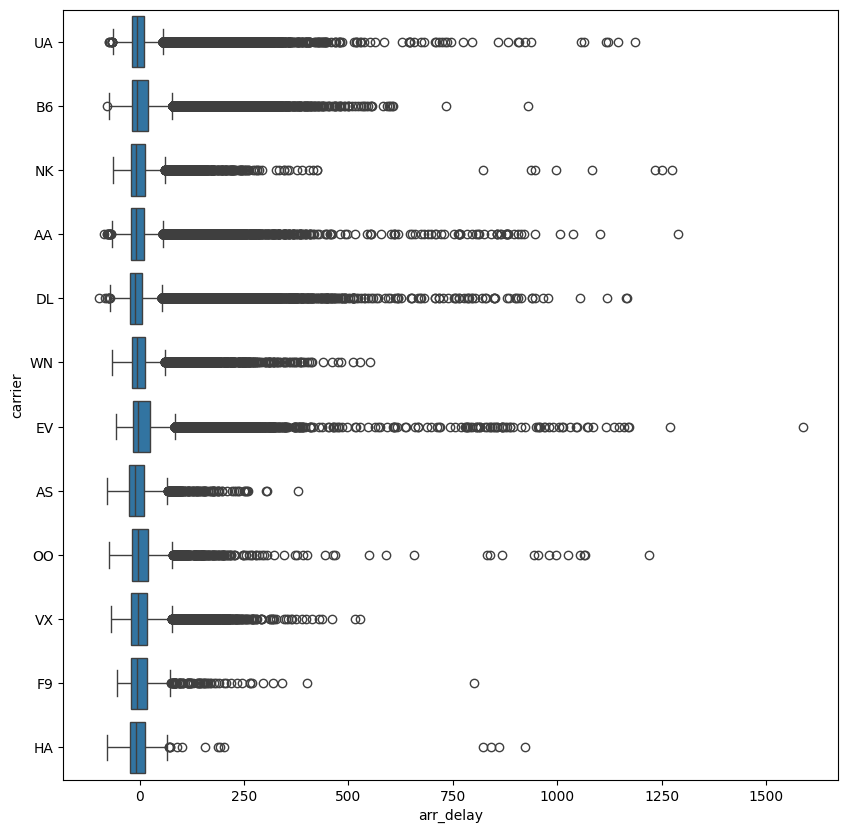

In [79]:
### 2-2) Since differences are observed, explore in detail using a boxplot.
plt.figure(figsize=(10,10))
sns.boxplot(data=df_final, x="arr_delay", y="carrier")

<Axes: xlabel='arr_delay', ylabel='carrier'>

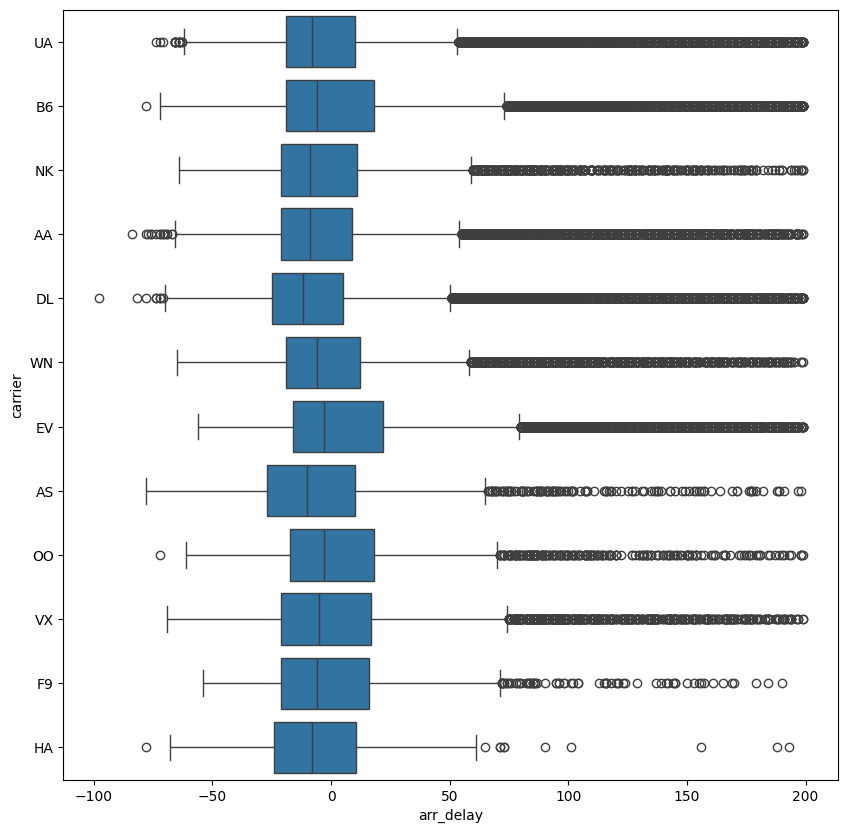

In [80]:
# Apply a filter to observe in detail
plt.figure(figsize=(10,10))
sns.boxplot(data=df_final[df_final.arr_delay < 200], x="arr_delay", y="carrier")

# The variation in arr_delay by carrier does not visually show a significant meaningful difference.

### Testing Categorical Data and Numerical Data
The methods for testing the relationship between these two types of data are divided into parametric and non-parametric approaches:
- **Parametric Method**: ANOVA
- **Non-Parametric Method**: Kruskal-Wallis
- **Note**: Parametric methods require various conditions to be met, which can make them difficult to apply, but they offer higher accuracy compared to non-parametric methods.

### One-Way ANOVA (Analysis of Variance)
- **Purpose**: Tests whether there are significant differences in the distribution of a numeric variable across categories.
- **Example**: Analyzing height distribution differences by gender.
- **Assumptions**:
  - **Normality**: Data within each group should be normally distributed.
  - **Equal Variance (Homoscedasticity)**: Variance across groups should be similar.
  - **Independence**: Observations should be independent of each other.
  - **Note**: If these assumptions are not met, the results of this test cannot be trusted.
- **Application in This Practice**: Verify the relationship between `arr_delay` distribution and categorical data (e.g., `engine`, `carrier`).
- **P-Value Threshold**:
  - If p-value ≤ 0.05, reject the null hypothesis (indicating significant differences).
  - **Note**: The p-value threshold can vary; there’s no absolute standard, but 0.05 is commonly used.

### Normality Test
- **Purpose**: For variance analysis (e.g., ANOVA), the data must satisfy normality.
- **Methods**: Test normality using various approaches, such as QQ-plot and Shapiro-Wilk test.

((array([-4.57770925, -4.38855194, -4.2859886 , ...,  4.2859886 ,
          4.38855194,  4.57770925]),
  array([ -98.,  -84.,  -82., ..., 1276., 1289., 1589.])),
 (np.float64(43.31356057220851),
  np.float64(7.104023113233141),
  np.float64(0.7829064086442739)))

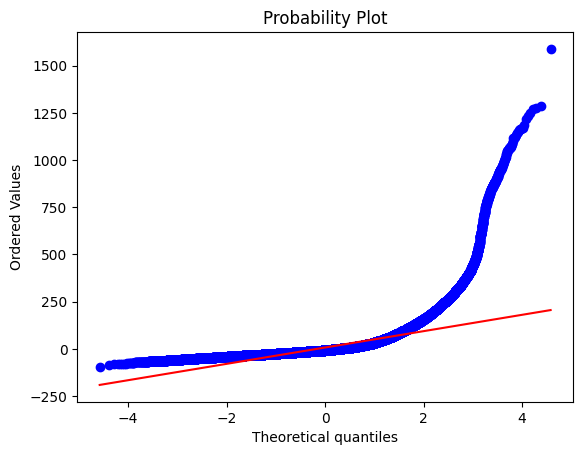

In [81]:
stats.probplot(df_final[target_column], dist=stats.norm, plot=plt)

### Normality Not Satisfied
- **Conclusion**: Since normality is not satisfied, testing for equal variance (homoscedasticity) is unnecessary (equal variance assumes normality).
- **Implication**: One-way ANOVA cannot be used to test numeric data.
- **Alternative**: Kruskal-Wallis Test (Non-Parametric Test)
  - **Advantage**: As a non-parametric test, it does not require normality or equal variance.
  - **Drawback**: Being non-parametric, the reliability of the test results is lower compared to parametric tests.

In [82]:
df_final[list_categorical_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294896 entries, 0 to 294895
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   month          294896 non-null  int64 
 1   day            294896 non-null  int64 
 2   dep_time       294896 non-null  object
 3   carrier        294896 non-null  object
 4   flight         294896 non-null  int64 
 5   tailnum        294896 non-null  object
 6   origin         294896 non-null  object
 7   dest           294896 non-null  object
 8   faa            288914 non-null  object
 9   name           288914 non-null  object
 10  type           258583 non-null  object
 11  manufacturer   258583 non-null  object
 12  model          258583 non-null  object
 13  engine         258583 non-null  object
 14  dest_datetime  294896 non-null  object
 15  wind_dir       294896 non-null  object
dtypes: int64(3), object(13)
memory usage: 36.0+ MB


In [83]:
list_meaningful_column_by_kruskall = []

for column_name in list_categorical_columns:
  list_by_value = []
  for value in df_final[column_name].dropna().unique():
      df_tmp = df_final[df_final[column_name] == value][target_column].dropna()
      list_by_value.append(np.array(df_tmp))
  statistic, pvalue = kruskal(*list_by_value)
  if pvalue <= 0.05:
    list_meaningful_column_by_kruskall.append(column_name)
  print(column_name, ", ",statistic,", ", pvalue)
print("all categorical columns : ", len(list_categorical_columns))
print("selected columns by kruskal : ", len(list_meaningful_column_by_kruskall), list_meaningful_column_by_kruskall)

month ,  4517.169007971446 ,  0.0
day ,  2011.547273385221 ,  0.0
dep_time ,  37326.48957806564 ,  0.0
carrier ,  4749.565614373608 ,  0.0
flight ,  29017.821278409894 ,  0.0
tailnum ,  11539.928221649188 ,  0.0
origin ,  2058.537468530962 ,  0.0
dest ,  4846.796839777051 ,  0.0
faa ,  4662.731186640077 ,  0.0
name ,  4662.731186640077 ,  0.0
type ,  13.178586013957197 ,  0.004265896440157533
manufacturer ,  2791.479839545662 ,  0.0
model ,  6264.888258101361 ,  0.0
engine ,  252.9007963705475 ,  6.685238031099385e-51
dest_datetime ,  87157.90797333283 ,  0.0
wind_dir ,  1798.8922942734612 ,  0.0
all categorical columns :  16
selected columns by kruskal :  16 ['month', 'day', 'dep_time', 'carrier', 'flight', 'tailnum', 'origin', 'dest', 'faa', 'name', 'type', 'manufacturer', 'model', 'engine', 'dest_datetime', 'wind_dir']


##### Insight
- **Finding**: In the Kruskal-Wallis test, all categorical data were found to have a significant relationship with the dependent variable (`arr_delay`).

-  Is the Kruskal-Wallis Test Used to Find Categorical Columns?
  - No, the Kruskal-Wallis test is not used to "find" categorical columns. Instead, it is a non-parametric statistical test used to determine whether there are significant differences in the distribution of a numeric dependent variable (e.g., `arr_delay`) across groups defined by a categorical independent variable (e.g., `engine`, `carrier`).

- Clarification
  - **Purpose**: It tests the null hypothesis that all groups have the same distribution. If the p-value is ≤ 0.05, it suggests the categorical variable significantly affects the numeric variable.
  - **Your Insight**: In your case, the test showed all categorical variables (e.g., `engine`, `carrier`) have a significant relationship with `arr_delay`.
  - **Not for Identification**: It assumes you already know your categorical columns and uses them to analyze their impact on the numeric outcome.

#### 2) Exploring numeric(continous) column

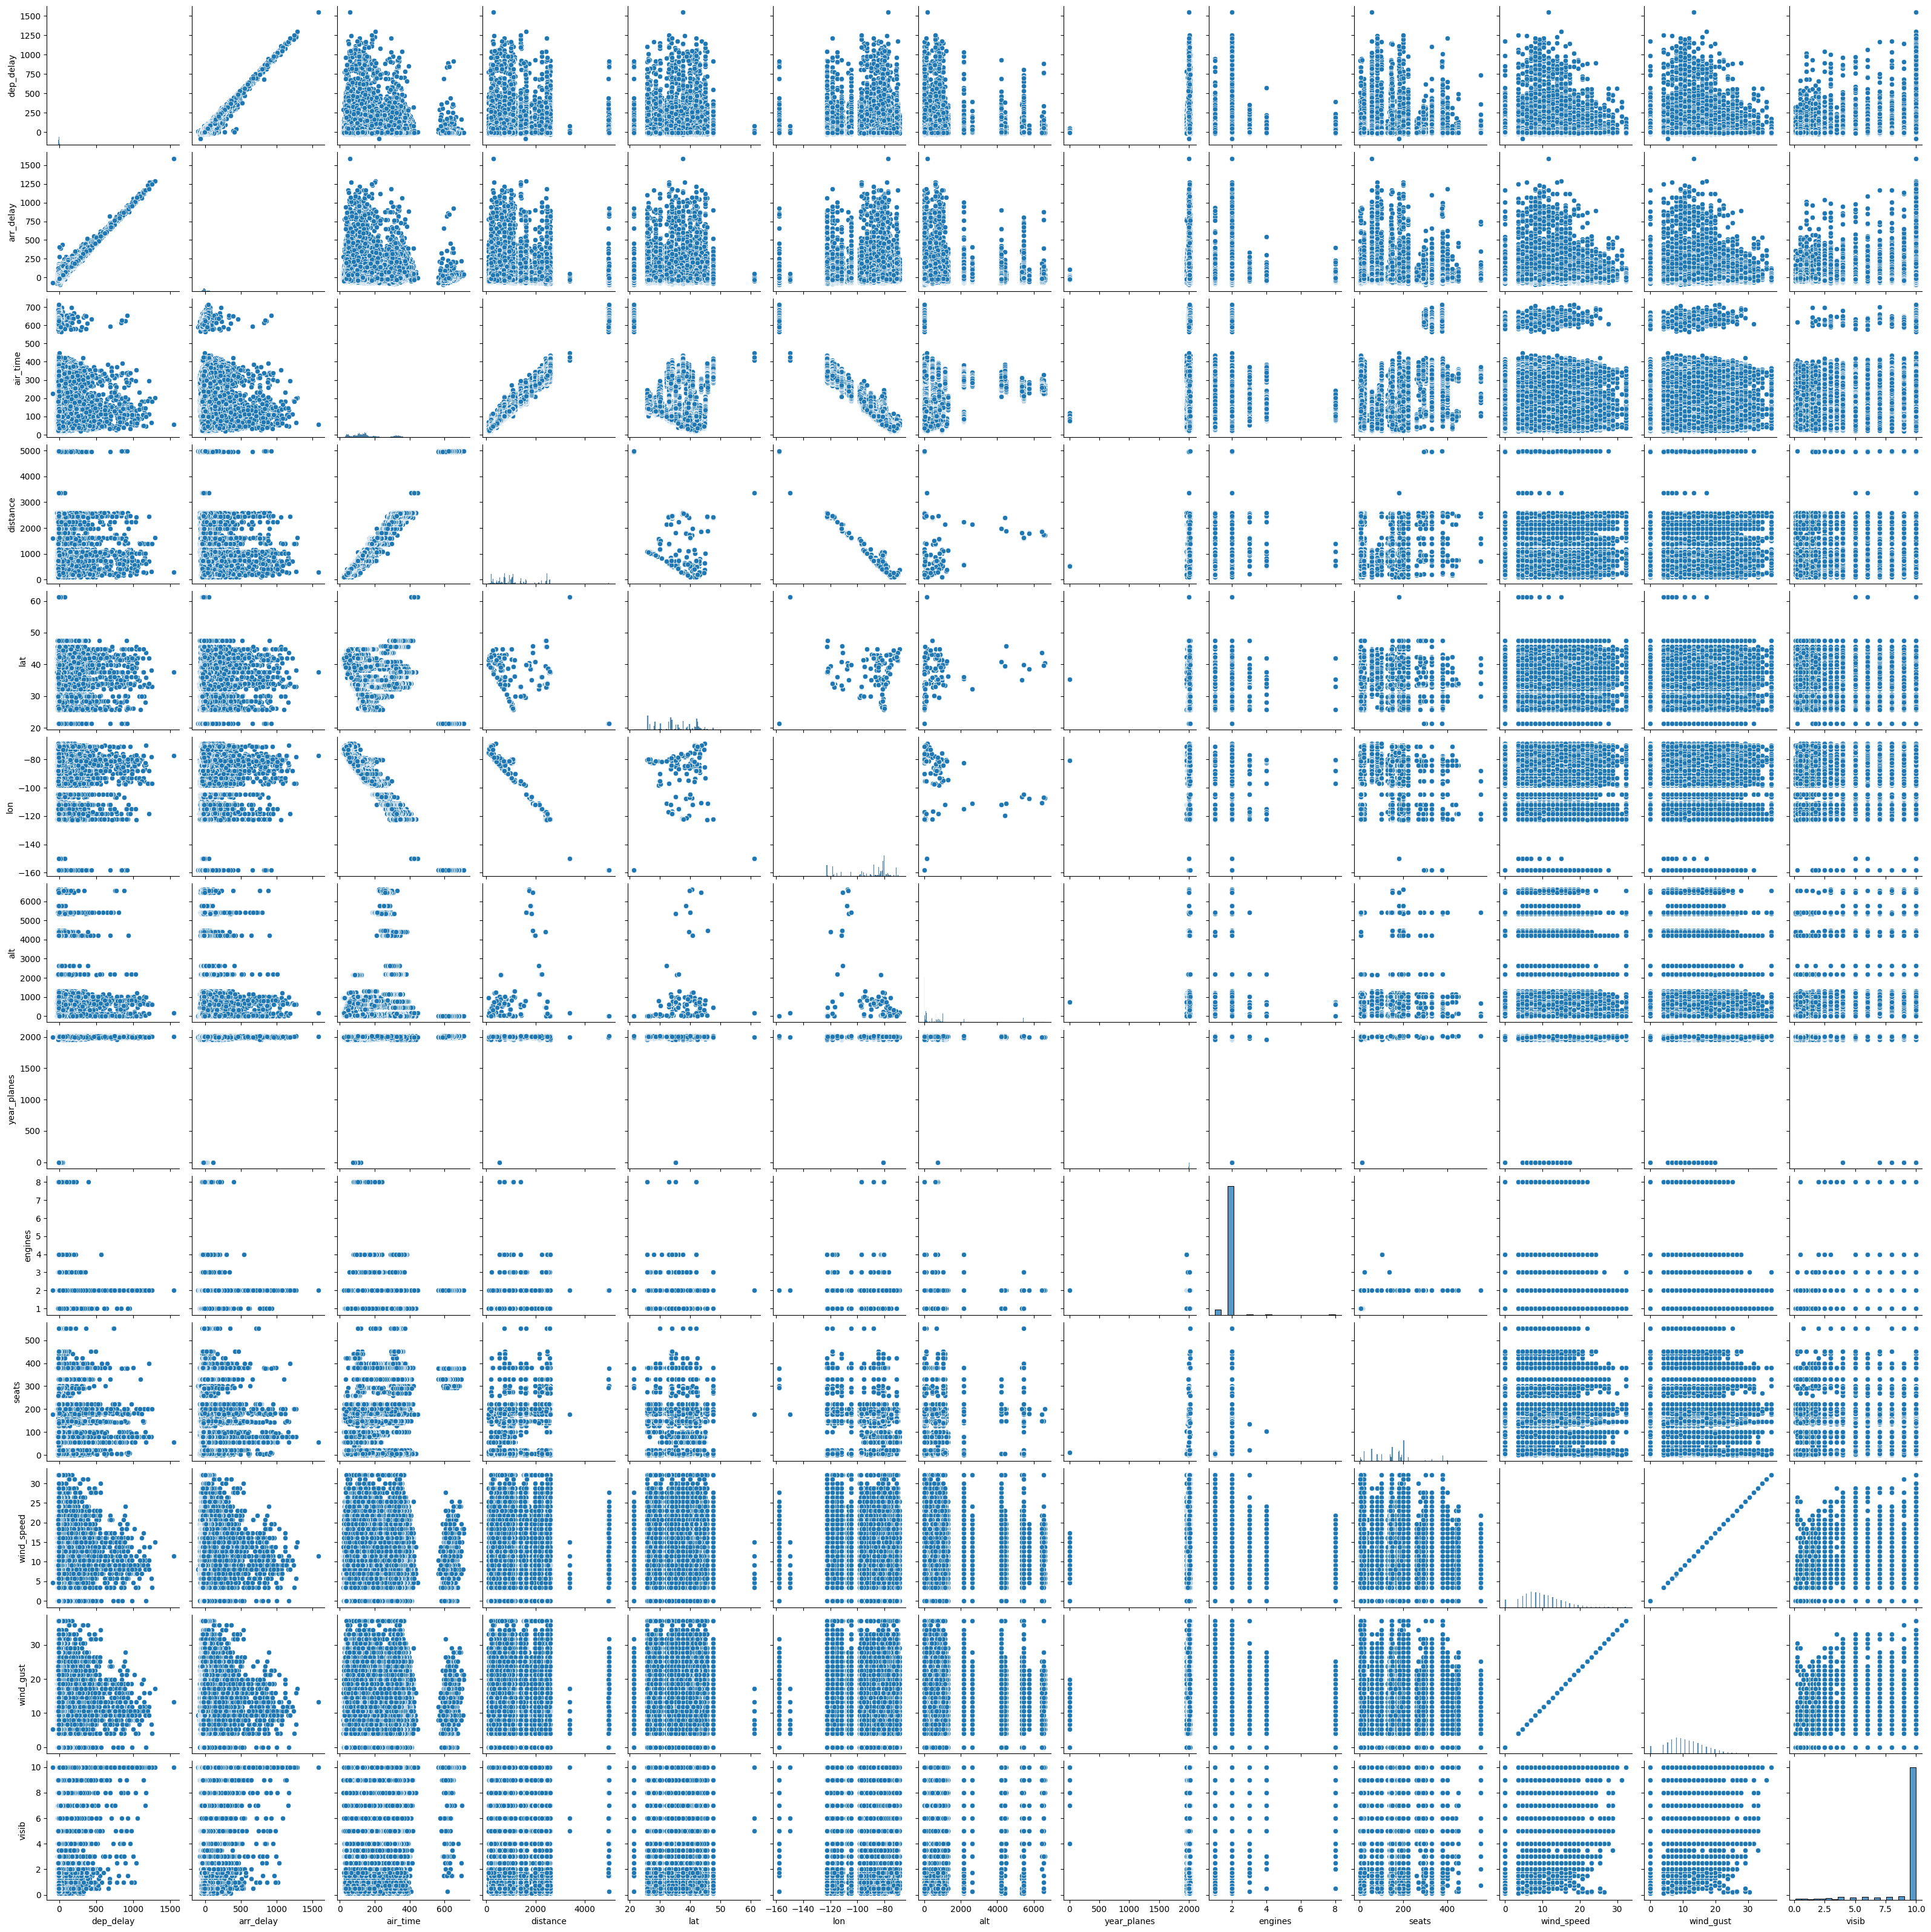

In [84]:
sns.pairplot(data=df_final.loc[:,list_numeric_columns])

<Axes: >

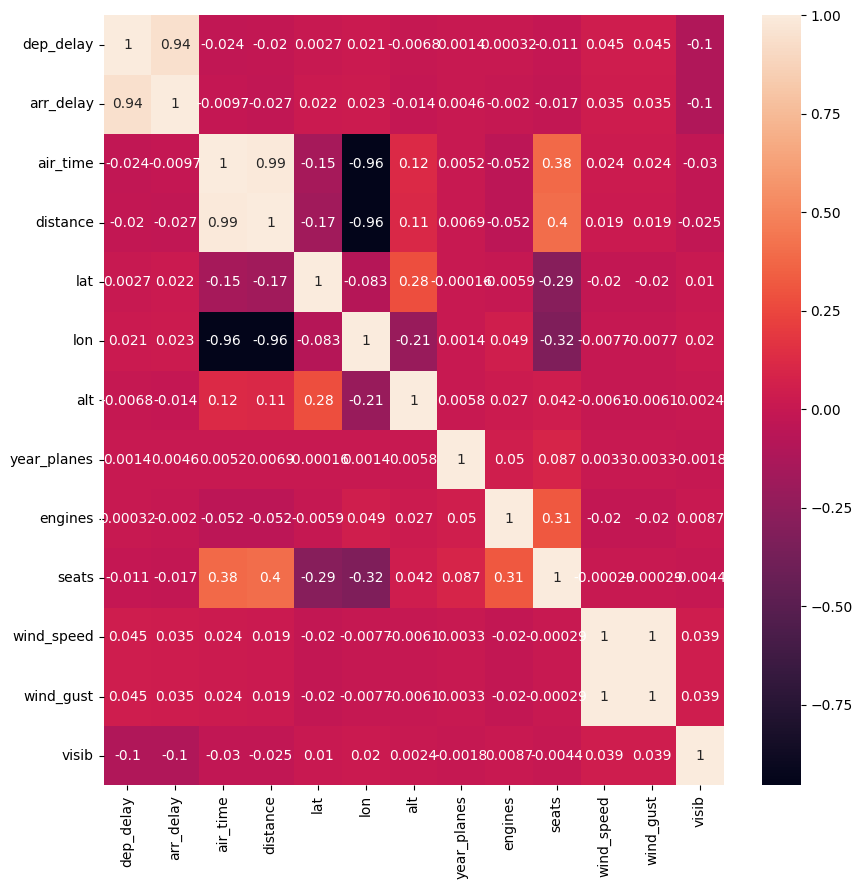

In [85]:
df_corr = df_final.loc[:,list_numeric_columns].corr()
plt.figure(figsize=(10,10))
sns.heatmap(df_corr, annot=True)

In [86]:
# Remove data with excessively high correlation. However, it’s necessary to verify whether the correlation values can be trusted.
index_corr_over_90 = np.where((abs(df_corr) > 0.90) & (df_corr != 1))
index_corr_over_90

(array([ 0,  1,  2,  2,  3,  3,  5,  5, 10, 11]),
 array([ 1,  0,  3,  5,  2,  5,  2,  3, 11, 10]))

In [87]:
len_corr_over_90 = len(index_corr_over_90[0])
left_columns = df_corr.columns[index_corr_over_90[0]]
right_columns = df_corr.columns[index_corr_over_90[1]]
for index in range(len_corr_over_90):
  print(left_columns[index], "<->", right_columns[index])

dep_delay <-> arr_delay
arr_delay <-> dep_delay
air_time <-> distance
air_time <-> lon
distance <-> air_time
distance <-> lon
lon <-> air_time
lon <-> distance
wind_speed <-> wind_gust
wind_gust <-> wind_speed


### Column Removal Decisions
1) **High Correlation**:
   - `air_time`, `lon`, `wind_speed`
   - These columns exhibit high correlation and will be removed.
2) **Duplicated Columns**:
   - `faa`, `origin`, `dest`
   - These were used as key values during the join process and are identical to keys in other data, so they will be removed.

In [88]:
list_removed_by_correlation = ["air_time", "lon", "wind_speed"]

## 3. Data Processing 2

### 3-1 Feature Selection
    1) high corrleation : air_time, lon, wind_speed
    2) duplicated columns : faa, origin, dest

In [89]:
list_removed_by_correlation

['air_time', 'lon', 'wind_speed']

In [90]:
column_removed = list_removed_by_correlation + [ "faa", "origin", "dest" ]
df_final = df_final.drop(column_removed, axis=1).copy()

### 3-2 Missing Values

In [91]:
print(len(df_final))
df_final.isna().sum()

294896


,0
month,0
day,0
dep_time,0
dep_delay,0
arr_delay,0
carrier,0
flight,0
tailnum,0
distance,0
name,5982


In [92]:
# Remove missing value data. It’s recommended to experiment with filling them using other methods as well.

df_filtered = df_final.dropna().reset_index()
df_filtered = df_filtered.drop(["index"], axis=1)
# df_filtered = df_final.dropna().resset_index(drop=True)
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245219 entries, 0 to 245218
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   month          245219 non-null  int64  
 1   day            245219 non-null  int64  
 2   dep_time       245219 non-null  object 
 3   dep_delay      245219 non-null  float64
 4   arr_delay      245219 non-null  float64
 5   carrier        245219 non-null  object 
 6   flight         245219 non-null  int64  
 7   tailnum        245219 non-null  object 
 8   distance       245219 non-null  float64
 9   name           245219 non-null  object 
 10  lat            245219 non-null  float64
 11  alt            245219 non-null  float64
 12  year_planes    245219 non-null  float64
 13  type           245219 non-null  object 
 14  manufacturer   245219 non-null  object 
 15  model          245219 non-null  object 
 16  engines        245219 non-null  float64
 17  seats          245219 non-nul

In [93]:
df_filtered.isna().sum()

,0
month,0
day,0
dep_time,0
dep_delay,0
arr_delay,0
carrier,0
flight,0
tailnum,0
distance,0
name,0


### 3-3 New Columns

In [94]:
pd.to_datetime(df_filtered["dest_datetime"])

,dest_datetime
0,2017-10-02 00:00:00
1,2017-10-01 05:00:00
2,2017-10-01 05:00:00
3,2017-10-01 05:00:00
4,2017-10-01 05:00:00
...,...
245214,2017-09-30 22:00:00
245215,2017-09-30 22:00:00
245216,2017-09-30 22:00:00
245217,2017-09-30 23:00:00


## Cyclical Nature of Time:
  - Hours and minutes represent cyclical patterns (e.g., 23:59 is very close to 00:00). When you keep time as a single feature (like "HHMM"), a model might interpret it linearly and not capture this cyclical relationship.
Separate Effects: Separating hours and minutes allows the model to learn the independent effects of each on arrival delays. For example:
Hour: Certain hours of the day (e.g., rush hours) might be more prone to delays.
  - Minute: The specific minute of departure within an hour might also have a subtle impact due to factors like airport traffic flow.
## Enhanced Model Flexibility:
  - Non-linear Relationships: By separating hours and minutes, the model has more flexibility to capture non-linear relationships between these features and arrival delays. For example, delays might increase significantly during certain hour ranges and then decrease again. A model using a single time feature might struggle to represent these complex patterns.

In [95]:
# Create hour, minute, and weekday data for the actual departure time
# Remove object-type data related to time
df_filtered["hour_dep"] = df_filtered.apply(lambda x : int(int(x.dep_time)/100), axis=1)
df_filtered["minute_dep"] = df_filtered.apply(lambda x : int(int(x.dep_time)%100), axis=1)
df_filtered["weekday_dep"] = pd.to_datetime(df_filtered["dest_datetime"]).dt.weekday
df_filtered = df_filtered.drop(["dep_time", "dest_datetime"], axis=1)

In [96]:
df_filtered.head(5)

,month,day,dep_delay,arr_delay,carrier,flight,tailnum,distance,name,lat,...,model,engines,seats,engine,wind_dir,wind_gust,visib,hour_dep,minute_dep,weekday_dep
0,10,1,193.0,182.0,UA,1537,N54711,1085.0,Miami International Airport,25.793200,...,737-724,2.0,149.0,Turbo-fan,40.0,10.594357,10.0,0,27,0
1,10,1,-6.0,-18.0,UA,1161,N37287,1400.0,George Bush Intercontinental Houston Airport,29.984400,...,737-824,2.0,149.0,Turbo-fan,360.0,18.540125,10.0,5,19,6
2,10,1,-1.0,-4.0,B6,27,N547JB,937.0,Orlando International Airport,28.429399,...,A320-232,2.0,200.0,Turbo-fan,360.0,18.540125,10.0,5,44,6
3,10,1,-4.0,-17.0,UA,761,N38446,733.0,Chicago O'Hare International Airport,41.978600,...,737-924ER,2.0,191.0,Turbo-fan,360.0,22.513008,10.0,5,46,6
4,10,1,-8.0,-4.0,NK,521,N675NK,1065.0,Fort Lauderdale Hollywood International Airport,26.072599,...,A321-231,2.0,379.0,Turbo-fan,360.0,18.540125,10.0,5,52,6


*df_filtered.select_dtypes(include=['int64', 'object'])*
-  This part selects columns from df_filtered that have a data type of either int64 (integer) or object (usually strings or mixed types). These are commonly used for representing categorical data.

In [97]:
list_categorical_columns = list(df_filtered.select_dtypes(include=['int64', 'object']).columns)
list_numeric_columns = list(df_filtered.select_dtypes(include=['float64']).columns)
print(len(df_filtered.columns))
print("categorical : ",len(list_categorical_columns))
print("numerical : ", len(list_numeric_columns))

24
categorical :  13
numerical :  10


### 3-4 Feature Transformation

In [98]:
df_filtered.head(5)

,month,day,dep_delay,arr_delay,carrier,flight,tailnum,distance,name,lat,...,model,engines,seats,engine,wind_dir,wind_gust,visib,hour_dep,minute_dep,weekday_dep
0,10,1,193.0,182.0,UA,1537,N54711,1085.0,Miami International Airport,25.793200,...,737-724,2.0,149.0,Turbo-fan,40.0,10.594357,10.0,0,27,0
1,10,1,-6.0,-18.0,UA,1161,N37287,1400.0,George Bush Intercontinental Houston Airport,29.984400,...,737-824,2.0,149.0,Turbo-fan,360.0,18.540125,10.0,5,19,6
2,10,1,-1.0,-4.0,B6,27,N547JB,937.0,Orlando International Airport,28.429399,...,A320-232,2.0,200.0,Turbo-fan,360.0,18.540125,10.0,5,44,6
3,10,1,-4.0,-17.0,UA,761,N38446,733.0,Chicago O'Hare International Airport,41.978600,...,737-924ER,2.0,191.0,Turbo-fan,360.0,22.513008,10.0,5,46,6
4,10,1,-8.0,-4.0,NK,521,N675NK,1065.0,Fort Lauderdale Hollywood International Airport,26.072599,...,A321-231,2.0,379.0,Turbo-fan,360.0,18.540125,10.0,5,52,6


In [99]:
for column_name in df_filtered.columns:
  print(column_name, df_filtered[column_name].nunique())

month 12
day 31
dep_delay 709
arr_delay 762
carrier 12
flight 3278
tailnum 3417
distance 195
name 104
lat 104
alt 97
year_planes 59
type 4
manufacturer 65
model 208
engines 4
seats 60
engine 7
wind_dir 37
wind_gust 28
visib 21
hour_dep 25
minute_dep 60
weekday_dep 7


In [100]:
# categorizing 'wind_dir' column (binning)
def category_wind_dir(value):
  value = float(value)
  rlt = 0
  if value < 60:
    rlt = 0
  elif (value >= 60) & (value < 120):
    rlt= 1
  elif (value >= 120) & (value < 180):
    rlt= 2
  elif (value >= 180) & (value < 240):
    rlt= 3
  elif (value >= 240) & (value < 300):
    rlt= 4
  else:
    rlt= 5
  return str(rlt)
df_filtered["wind_dir_category"] = df_filtered["wind_dir"].apply(lambda x : category_wind_dir(x))

In [101]:
df_filtered = df_filtered.drop("wind_dir", axis=1)

In [102]:
list_categorical_columns = list(df_filtered.select_dtypes(include=['int64', 'object']).columns)
list_numeric_columns = list(df_filtered.select_dtypes(include=['float64']).columns)
print(len(df_filtered.columns))
print("categorical : ",len(list_categorical_columns))
print("numerical : ", len(list_numeric_columns))

24
categorical :  13
numerical :  10


##### Encoding
- If we decide to use tree-based machine learning models, it’s possible to perform discrete (ordinal) encoding for categorical data instead of one-hot
encoding.
  - #### What is Discrete (Ordinal) Encoding?
    - **Definition**: Discrete or ordinal encoding assigns a unique integer to each category in a categorical column. Unlike one-hot encoding, it keeps the data in a single column rather than creating multiple binary columns.

- When there are too many categories, one-hot encoding can lead to an excessive number of data columns, which may hinder training.


In [103]:
for column_name in list_categorical_columns:
    ce = LabelEncoder()
    ce.fit(df_filtered[column_name])
    df_filtered[column_name] = ce.transform(df_filtered[column_name])

In [104]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245219 entries, 0 to 245218
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   month              245219 non-null  int64  
 1   day                245219 non-null  int64  
 2   dep_delay          245219 non-null  float64
 3   arr_delay          245219 non-null  float64
 4   carrier            245219 non-null  int64  
 5   flight             245219 non-null  int64  
 6   tailnum            245219 non-null  int64  
 7   distance           245219 non-null  float64
 8   name               245219 non-null  int64  
 9   lat                245219 non-null  float64
 10  alt                245219 non-null  float64
 11  year_planes        245219 non-null  float64
 12  type               245219 non-null  int64  
 13  manufacturer       245219 non-null  int64  
 14  model              245219 non-null  int64  
 15  engines            245219 non-null  float64
 16  se

In [105]:
df_filtered

,month,day,dep_delay,arr_delay,carrier,flight,tailnum,distance,name,lat,...,model,engines,seats,engine,wind_gust,visib,hour_dep,minute_dep,weekday_dep,wind_dir_category
0,9,0,193.0,182.0,9,1033,1449,1085.0,62,25.793200,...,39,2.0,149.0,3,10.594357,10.0,0,27,0,0
1,9,0,-6.0,-18.0,9,801,912,1400.0,38,29.984400,...,60,2.0,149.0,3,18.540125,10.0,5,19,6,5
2,9,0,-1.0,-4.0,2,17,1450,937.0,71,28.429399,...,109,2.0,200.0,3,18.540125,10.0,5,44,6,5
3,9,0,-4.0,-17.0,9,507,1021,733.0,20,41.978600,...,68,2.0,191.0,3,22.513008,10.0,5,46,6,5
4,9,0,-8.0,-4.0,7,353,1922,1065.0,33,26.072599,...,113,2.0,379.0,3,18.540125,10.0,5,52,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245214,8,29,-7.0,-25.0,2,1239,727,209.0,95,43.111198,...,151,2.0,20.0,3,17.215830,10.0,22,38,5,5
245215,8,29,-4.0,-19.0,2,1385,817,301.0,13,42.940498,...,151,2.0,20.0,3,17.215830,10.0,22,41,5,5
245216,8,29,3.0,-9.0,5,344,521,1620.0,28,39.861698,...,108,2.0,182.0,3,15.891535,10.0,22,48,5,5
245217,8,29,2.0,-10.0,2,477,662,187.0,36,42.364300,...,151,2.0,20.0,3,18.540125,10.0,23,19,5,5


##### Normalization (MinMaxScaler)

In [106]:
df_feature = df_filtered.drop("arr_delay", axis=1).copy()
df_label = df_filtered["arr_delay"].copy()

- scaler.fit_transform(df_feature):
  - This part applies the MinMaxScaler to the df_feature DataFrame.
  - It essentially learns the minimum and maximum values of each column in your dataset (df_feature) and then transforms the data so that all values fall within a specific range, typically between 0 and 1.

In [107]:
scaler = MinMaxScaler()
df_feature = pd.DataFrame(scaler.fit_transform(df_feature), columns=df_feature.columns)

In [108]:
df_feature.head(2)

,month,day,dep_delay,carrier,flight,tailnum,distance,name,lat,alt,...,model,engines,seats,engine,wind_gust,visib,hour_dep,minute_dep,weekday_dep,wind_dir_category
0,0.818182,0.0,0.140774,0.818182,0.315227,0.424180,0.202863,0.601942,0.112267,0.000606,...,0.188406,0.333333,0.268603,0.5,0.285714,1.0,0.000000,0.457627,0.0,0.0
1,0.818182,0.0,0.014585,0.818182,0.244431,0.266979,0.267280,0.368932,0.217427,0.014087,...,0.289855,0.333333,0.268603,0.5,0.500000,1.0,0.208333,0.322034,1.0,1.0


## 4. Model Analysis

### 4-1. Base Model Learning

In [109]:
X_train, X_test, y_train, y_test = train_test_split(df_feature, df_label, test_size = 0.3, random_state=random_state)

In [110]:
regr = RandomForestRegressor(max_depth=4, random_state=random_state)
regr.fit(X_train, y_train)

RandomForestRegressor(max_depth=4, random_state=1234)

In [111]:
y_prd=regr.predict(X_test)
print("rmse : %f"%(mean_squared_error(y_test, y_prd)**0.5))

rmse : 18.740307


### 4-2. Optimization 1

In [112]:
hyper_params = {'n_estimators' : [10, 15, 20, 25],
                'max_depth' : [4, 8, 10],
                'min_samples_leaf' : [4, 8, 10],
                'max_features' : [0.5, 0.7, 0.9]
               }

rf_regr = RandomForestRegressor(random_state = random_state, n_jobs = -1)
grid_cv = GridSearchCV(rf_regr, param_grid = hyper_params, cv = 3, n_jobs = -1)
grid_cv.fit(X_train, y_train)

print('best model hyper-parameter : ', grid_cv.best_params_)

best model hyper-parameter :  {'max_depth': 10, 'max_features': 0.9, 'min_samples_leaf': 4, 'n_estimators': 25}


In [113]:
y_prd=grid_cv.predict(X_test)
print("rmse : %f"%(mean_squared_error(y_test, y_prd)**0.5))

rmse : 17.933205


### 4-3. Optimization 2

### Bagging vs. Boosting

#### Bagging (Bootstrap Aggregating)
- **Process**:
  - Bagging starts with a single dataset and creates multiple "versions" of it by sampling with replacement. This means each sample (or subset) can have some data points repeated and others left out—think of it like drawing marbles from a bag, putting them back, and drawing again. Each of these subsets is used to train a separate, independent model (usually a decision tree in the case of Random Forest).
    - Imagine you’re asking a group of people to guess the weight of a cake. If each person guesses independently based on slightly different clues (subsets of data), averaging their guesses cancels out individual mistakes, giving you a better estimate than any single guess. Bagging does this with models.

  - Prediction: For regression, the predictions from all models are averaged; for classification, they "vote" (majority wins).
- **Key Feature**
  - Improves generalization (reduces overfitting).
    - The randomness in sampling reduces correlation between the models, making their errors less aligned.

  - Since each model is independent, you can train them simultaneously, speeding up the process on modern hardware.
- **Example**: RandomForestRegressor uses bagging with decision trees.

#### Boosting
- **Process**:
  - Boosting takes a sequential approach. It starts by training a single model on the full dataset (or a sample). Then, it evaluates where that model went wrong—focusing on the errors—and builds the next model to fix those mistakes. This process repeats, with each new model paying more attention to the data points the previous models struggled with.
    - Training: Models are built one after another, each learning from the residuals (errors) of the prior ones.
    - Weighting: Data points that are poorly predicted get higher "weights" (importance) in subsequent rounds, forcing the next model to focus on them.
    - Prediction: The final output combines all models, often with a weighted sum where stronger models contribute more.
      - Think of boosting like a team of students studying for a test. The first student takes a practice exam and misses some questions. The second student focuses on those missed questions, and so on. By the end, the team collectively nails the whole test. Boosting iteratively refines the model until it’s a "strong learner."
- **Advantages**:
  - Higher Accuracy (Bias Reduction): Boosting turns weak learners (e.g., shallow trees) into a powerful ensemble by minimizing errors step-by-step.
  
  - Adaptability: It excels at fitting complex patterns in the data because it keeps refining its focus on hard-to-predict cases.
- **Disadvantages**:
  - Prone to overfitting.
  - Sequential process (no parallel processing).
- **Example**: XGBoost or GradientBoostingRegressor uses boosting.

#### Comparison
- **Bagging**: Focuses on reducing variance, good for unstable models (e.g., deep trees).
- **Boosting**: Focuses on reducing bias, builds a stronger learner incrementally.

## Comparison: Bagging vs. Boosting

### Core Focus
- **Bagging**: Reduces *variance*. It’s great for high-variance models (e.g., deep decision trees) that fluctuate wildly with small data changes. By averaging, it stabilizes predictions.
- **Boosting**: Reduces *bias*. It’s designed for weak learners (e.g., shallow trees) that consistently underperform, building them up into a strong, low-bias model.

### How They Handle Errors
- **Bagging**: Errors in individual models are uncorrelated due to random sampling, so they cancel out in the average.
- **Boosting**: Errors are systematically reduced by focusing subsequent models on the residuals, making it more deliberate but riskier if the errors are noisy.

### Parallel vs. Sequential
- **Bagging**: Independent models = parallel training = faster on multi-core systems.
- **Boosting**: Sequential training = slower, as each step waits for the previous one.

### When to Use Each
- **Bagging**: Use it when your base model is complex and prone to overfitting (e.g., Random Forest for noisy datasets).
- **Boosting**: Use it when you need maximum predictive power and your base model is too simple (e.g., XGBoost for competitions or critical predictions).

### Real-World Analogy
- **Bagging**: A panel of judges scores a performance independently, and you take the average score. No judge influences another.
- **Boosting**: A coach trains an athlete, sees their weaknesses, adjusts the training plan, and repeats until the athlete excels.

### XGBoost (Extreme Gradient Boosting)
1) Abbreviation for **Extreme Gradient Boosting**.
  - XGBoost is an ensemble method that builds a series of decision trees sequentially, where each tree corrects the errors of the previous ones. It uses gradient boosting, a technique that minimizes a loss function (e.g., mean squared error for regression, log loss for classification) by iteratively adding trees that "learn" from the residuals (prediction errors) of the prior models. The "extreme" part comes from its engineering optimizations, which make it faster and more efficient than traditional gradient boosting.

2) A library that supports **parallel training** of the Gradient Boosting algorithm.

3) Capable of handling both **regression** and **classification** tasks.

4) Provides **regularization** features (e.g., L1, L2 penalties) to prevent overfitting.

5) Supports **early stopping** to halt training when performance stops improving.

In [114]:
hyper_params_xgb = {"colsample_bytree":[1.0],
                    "min_child_weight":[1.0,1.2],
                    'max_depth': [4, 8, 10],
                    'n_estimators': [10, 15, 20]}

xgb_regr = XGBRegressor(n_estimators = 500, max_depth = 9,min_child_weight= 1.2,colsample_bytree = 1.0)
grid_cv_xgb = GridSearchCV(xgb_regr, param_grid = hyper_params_xgb, cv = 3, n_jobs = -1)
grid_cv_xgb.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=1.0,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, ma...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=9, max_leaves=None,
                                    min_child_weight=1.2, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=500,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [1.0], 'max_depth': [4, 8, 10],
                         'min_child_weight': [1.0, 1.2],
                         'n_estimators': [10, 15, 20]})

In [115]:
y_prd=grid_cv_xgb.predict(X_test)
print("rmse : %f"%(mean_squared_error(y_test, y_prd)**0.5))

rmse : 19.583051


### 4-4. Model Analysis

In [116]:
rf_final_model = RandomForestRegressor(**grid_cv.best_params_)
rf_final_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, max_features=0.9, min_samples_leaf=4,
                      n_estimators=25)

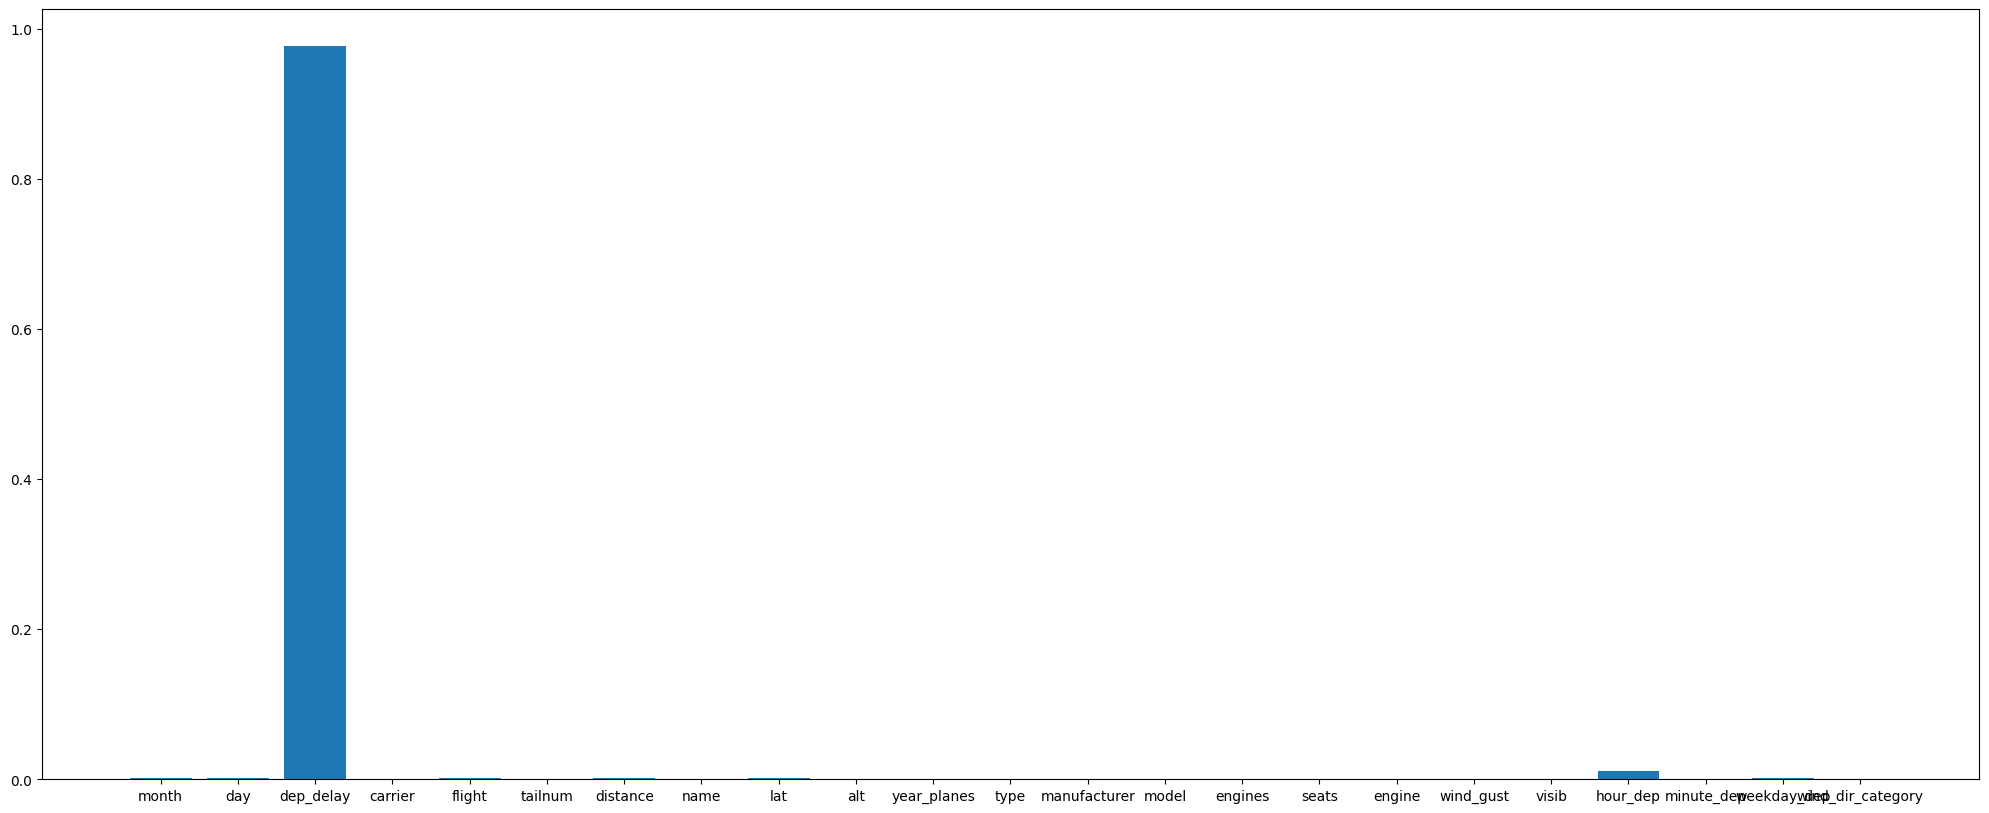

In [117]:
plt.figure(figsize=(25,10))
ax = plt.bar(list(df_feature.columns),rf_final_model.feature_importances_)

### 4-5. Adittional Analysis
- I want to gain insights into how much other features, besides `dep_delay`, affect flight delay time (`arr_delay`).

In [118]:
df_feature_added = df_filtered.drop(["arr_delay", "dep_delay"], axis=1).copy()

In [119]:
X_train_added, X_test_added, y_train_added, y_test_added = train_test_split(df_feature_added, df_label, test_size = 0.3, random_state=random_state)

In [120]:
hyper_params_xgb = {"colsample_bytree":[1.0],
                    "min_child_weight":[1.0,1.2],
                    'max_depth': [4, 8, 10],
                    'n_estimators': [10, 15, 20, 25]}

xgb_regr = XGBRegressor(n_estimators = 500, max_depth = 9,min_child_weight= 1.2,colsample_bytree = 1.0)
grid_cv_xgb = GridSearchCV(xgb_regr, param_grid = hyper_params_xgb, cv = 3, n_jobs = -1)
grid_cv_xgb.fit(X_train_added, y_train_added)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=1.0,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, ma...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=9, max_leaves=None,
                                    min_child_weight=1.2, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=500,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [1.0], 'max_depth': [4, 8, 10],
                         'min_child_weight': [1.0, 1.2],
                         'n_estimators': [10, 15, 20, 25]})

In [121]:
xgb_added_model = XGBRegressor(**grid_cv.best_params_)
xgb_added_model.fit(X_train_added, y_train_added)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:52:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "max_features", "min_samples_leaf" } are not used.

  warnings.warn(smsg, UserWarning)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_features=0.9,
             max_leaves=None, min_child_weight=None, min_samples_leaf=4,
             missing=nan, monotone_constraints=None, multi_strategy=None,
             n_estimators=25, n_jobs=None, ...)

In [122]:
y_prd=grid_cv_xgb.predict(X_test_added)
print("rmse : %f"%(mean_squared_error(y_test, y_prd)**0.5))

rmse : 43.889269


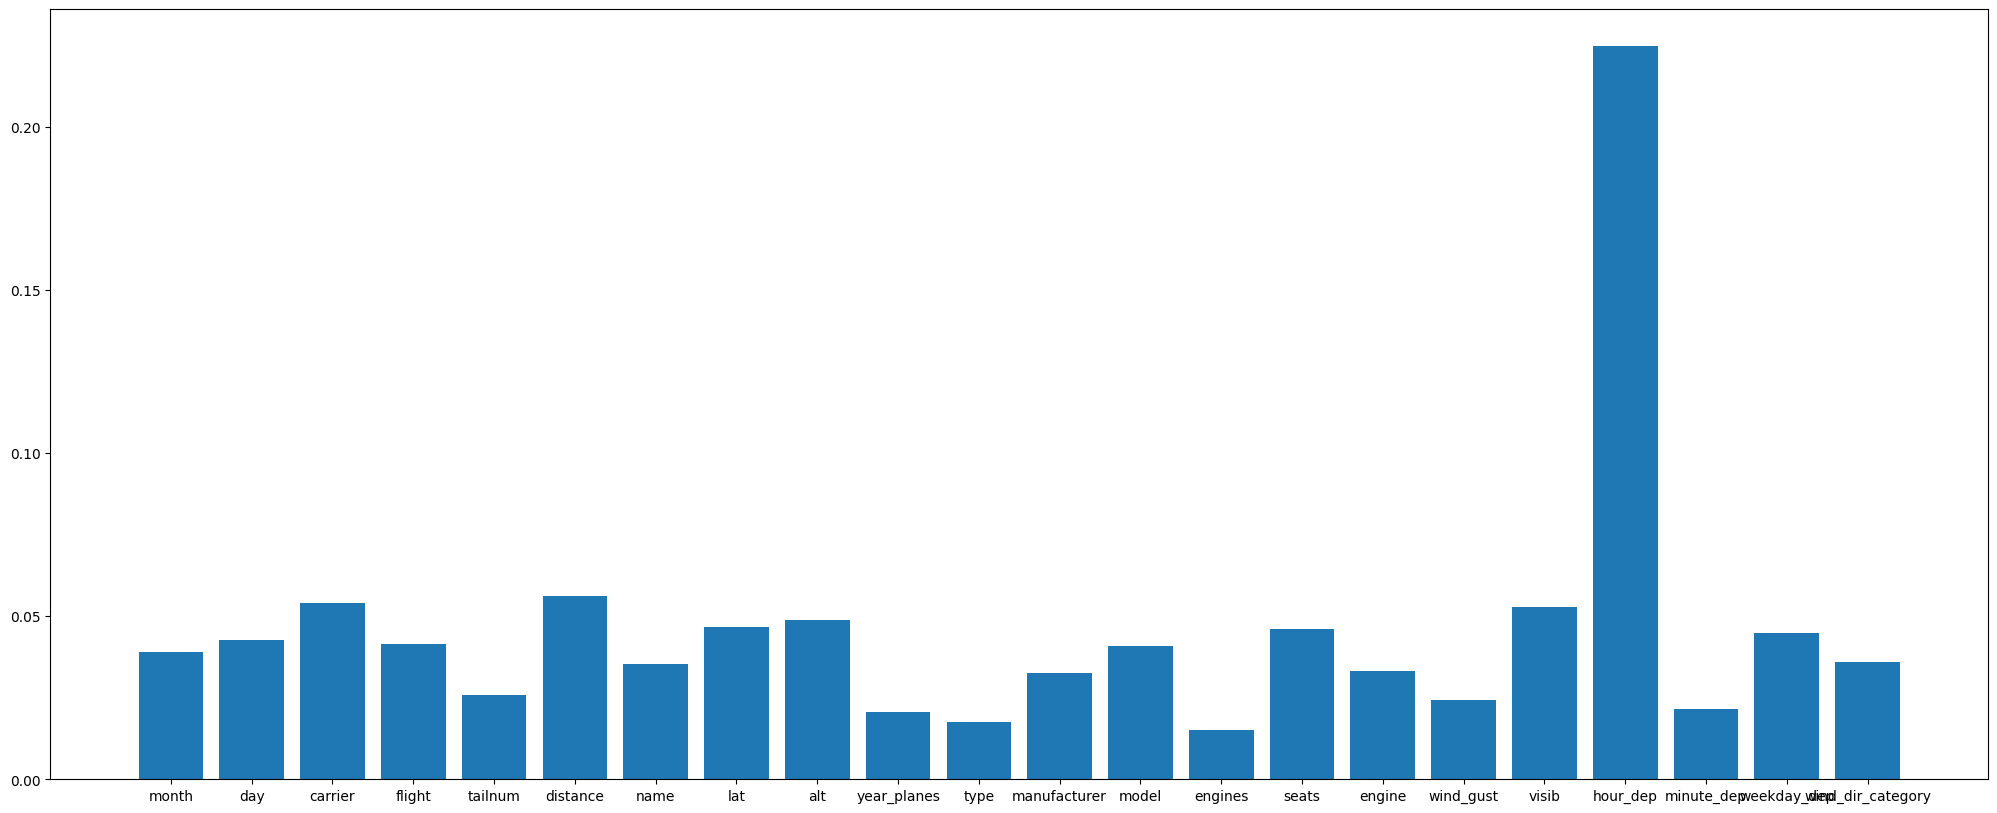

In [123]:
plt.figure(figsize=(25,10))
ax = plt.bar(list(df_feature_added.columns),xgb_added_model.feature_importances_)